# Exploratory Data Analysis (EDA)
## What is Exploratory Data Analysis and Why is it Important?

Exploratory Data Analysis (EDA) is a critical step in the data science workflow. Before building predictive models, it is important to thoroughly understand the dataset, its structure, and potential issues that may affect the analysis.

EDA helps us:

- Better understand the structure and distribution of the data

- Identify data quality issues, such as missing values or inconsistent formats

- Discover relationships between variables

- Generate hypotheses about potential drivers of churn

- Identify features that may be useful for predictive modeling

Through systematic exploration of the dataset, we can develop a deeper understanding of the underlying patterns and prepare the data for subsequent modeling steps.

# Table of Contents
1. [Basic Statistics](#basic_statistics)

2. [Data Quality Investigation](#data_quality_investigation)
    - [Missing Values in TotalCharges](#investigating-missing-values-in-totalcharges)

3. [Variable Exploration and Structure](#variable-exploration-and-structure)
    - [CutomerID](#customerid)
    - [Gender](#gender)
    - [SeniorCitizen](#seniorcitizen)
    - [Partner](#partner)
    - [Dependents](#dependents)
    - [Tenure](#tenure)
    - [PhoneService](#phoneservice)
    - [MultipleLines](#multiple-lines)
    - [InternetService](#internetservice)
    - [OnlineSecurity](#onlinesecurity)
    - [OnlineBackup](#onlinebackup)
    - [DeviceProtection](#deviceprotection)
    - [TechSupport](#techsupport)
    - [Streaming Services](#streamingtv-and-streamingmovies)
    - [Contracts](#contracts)
    - [PaperlessBilling](#paperlessbilling)
    - [PaymentMethod](#paymentmethod)
    - [MontlyCharges](#monthlycharges)
    - [TotalCharges](#totalcharges)
    - [Summary](#summary-and-key-findings-of-variable-exploration)


3. [Relation with Churn](#relationship-between-customer-characteristics-and-churn)
    - [SeniorCitizen](#churn-and-seniorcitizen)
    - [Partner](#churn-and-partner)
    - [Dependents](#churn-and-dependents)
    - [Tenure](#churn-and-tenure)
    - [PhoneService](#churn-and-phoneservice)
    - [MultipleLines](#churn-and-multiplelines)
    - [InternetService](#churn-and-internetservice)
    - [Additonal Services](#churn-and-onlinesecurity-onlinebackup-deviceprotection-techsupport-streamingtv-streamingmovies)
    - [Contracts](#churn-and-contracts)
    - [PaperlessBilling](#churn-and-paperlessbilling)
    - [PaymentMethod](#churn-and-paymentmethod)
    - [MontlyCharges](#churn-and-monthlycharges)
    - [TotalCharges](#churn-and-totalcharges)
    - [Summary](#conclusion-of-the-relationship-analysis)

4. [EDA Summary](#final-conclusion-of-exploratory-data-analysis)

## Basic Statistics

Some initial descriptive statistics were already explored in the previous notebook:

- [01_data_overview.ipynb](./01_data_overview.ipynb)

In this notebook, we expand on that initial inspection and analyze:

- distributions of individual features

- relationships between features and churn

- potential patterns that may help explain customer behavior

This step provides important context before proceeding to feature engineering and predictive modeling.

In [72]:
import polars as pl

df_eda_start = pl.read_csv("./data/processed/02_train_dataset.csv")
# Basic statistics of the data:
continuous_columns = ["tenure", "MonthlyCharges", "TotalCharges"]  # These are the columns that are numeric; we treat them as continuous for simplicity.
categorical_columns = [col for col in df_eda_start.columns if col not in continuous_columns and col != "customerID"]  # These are columns that are not numeric and not customerID; we treat them as categorical.

print("Data Shape:", df_eda_start.shape)


print("Basic statistics of the data:")
for col in df_eda_start.columns:
    if col in continuous_columns:
        print(f"\nStatistics for column: {col}")
        print(df_eda_start.select(pl.col(col)).describe())
        print(f"Number of missing values in column {col}: {df_eda_start.select(pl.col(col).is_null().sum())}")
    elif col in categorical_columns:
        print(f"\nValue counts for column: {col}")
        print(df_eda_start.select(pl.col(col).value_counts()))
        print(f"Number of unique values in column {col}: {df_eda_start.select(pl.col(col).n_unique())}")
        print(f"Number of missing values in column {col}: {df_eda_start.select(pl.col(col).is_null().sum())}")

Data Shape: (5634, 21)
Basic statistics of the data:

Value counts for column: gender
shape: (2, 1)
┌─────────────────┐
│ gender          │
│ ---             │
│ struct[2]       │
╞═════════════════╡
│ {"Male",2844}   │
│ {"Female",2790} │
└─────────────────┘
Number of unique values in column gender: shape: (1, 1)
┌────────┐
│ gender │
│ ---    │
│ u32    │
╞════════╡
│ 2      │
└────────┘
Number of missing values in column gender: shape: (1, 1)
┌────────┐
│ gender │
│ ---    │
│ u32    │
╞════════╡
│ 0      │
└────────┘

Value counts for column: SeniorCitizen
shape: (2, 1)
┌───────────────┐
│ SeniorCitizen │
│ ---           │
│ struct[2]     │
╞═══════════════╡
│ {1,902}       │
│ {0,4732}      │
└───────────────┘
Number of unique values in column SeniorCitizen: shape: (1, 1)
┌───────────────┐
│ SeniorCitizen │
│ ---           │
│ u32           │
╞═══════════════╡
│ 2             │
└───────────────┘
Number of missing values in column SeniorCitizen: shape: (1, 1)
┌───────────────┐
│ Se

## Data Quality Investigation

### Investigating Missing Values in `TotalCharges`

In the previous notebook, [01_data_overview.ipynb](./01_data_overview.ipynb), we identified one notable data quality issue: the column `TotalCharges` contains **9 missing values**.

Before deciding how to handle these missing values, it is important to understand why they appear in the dataset.

To investigate this issue, we will go through the following steps:

1. Verify that the data was loaded correctly  
Sometimes dataframe libraries such as Pandas or Polars may introduce missing values when a column contains mixed data types. In such cases, values that cannot be parsed correctly may be converted to `null`.

2. Inspect the full rows containing missing values
Examining the full records may reveal patterns that explain why the values are missing. For example, these customers may have recently joined the service and therefore have no accumulated charges yet.

3. Formulate hypotheses about how the missing values occurred
Based on the dataset structure and domain knowledge, we can propose plausible explanations for the missing values.

4. Decide how to handle the missing values
After understanding the cause, we can determine the most appropriate strategy, such as:
   - imputing values
   - calculating them from other columns
   - removing affected rows
   - or leaving them unchanged if they carry meaningful information.

This investigation will help ensure that data quality issues are addressed before proceeding with feature engineering and modeling.

### Step 1: Verify That the Data Was Loaded Correctly

The first step is to ensure that the missing values were not introduced during data loading.

Sometimes dataframe libraries such as Pandas or Polars may produce missing values when a column contains mixed data types. If a value cannot be parsed correctly, it may be automatically converted to null.

To verify this, we first retrieve the customer IDs corresponding to the missing values in the TotalCharges column.

In [73]:
col = "TotalCharges"
print(list(df_eda_start.filter(pl.col(col).is_null())["customerID"]))


['4472-LVYGI', '3115-CZMZD', '5709-LVOEQ', '4367-NUYAO', '1371-DWPAZ', '7644-OMVMY', '3213-VVOLG', '2520-SGTTA', '2923-ARZLG']


Inspecting the Raw Data

Next, we verify whether the missing values are already present in the original CSV file.

Because the dataset is relatively small, we could easily inspect the rows using Excel or another spreadsheet viewer.

![image](./images/columns_missing_data_excel.png)


The values appear to be missing in Excel as well. However, spreadsheet software sometimes hides certain formatting issues, so it is safer to inspect the raw CSV file directly.

To do this, we open the CSV file as a text document and print the rows corresponding to the problematic customer IDs.

In [74]:
# read data as text document and print the problematic lines
col = "TotalCharges"
problematic_customerIDs = list(df_eda_start.filter(pl.col(col).is_null())["customerID"])
with open("./data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv", "r") as f:
    lines = f.readlines()
    for line in lines:
        if line.startswith("customerID,"):
            print(line) # print the header
        for customerID in problematic_customerIDs:
            if line.startswith(customerID + ","):
                print(line)


customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn

4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55, ,No

3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25, ,No

5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85, ,No

4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75, ,No

1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05, ,

**Conclusion**

After examining the underlying CSV file, we can confirm that the TotalCharges values for these records are truly missing in the source dataset.

This means that the missing values were not introduced during data loading or preprocessing, but are part of the original dataset itself.

In the next step, we will examine the affected records more closely to determine why these values might be missing.

### Step 2: Inspect the Full Rows Containing Missing Values

Sometimes additional columns in the dataset can provide useful context for understanding missing values. For example, in other datasets we might encounter patterns such as:
```json
    {
    "current_location": null,
    "tracking_services": "disabled"
    }
```
Similarly, examining the full records of customers with missing TotalCharges may reveal patterns that help explain why these values are missing.

To investigate this, we first display all rows where `TotalCharges` is null.

In [75]:
# helps us see the whole table without truncation, which is useful for debugging
col = "TotalCharges"
pl.Config.set_tbl_rows(-1)
df_eda_start.filter(pl.col(col).is_null())


customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
str,str,i64,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,str
"""4472-LVYGI""","""Female""",0,"""Yes""","""Yes""",0,"""No""","""No phone service""","""DSL""","""Yes""","""No""","""Yes""","""Yes""","""Yes""","""No""","""Two year""","""Yes""","""Bank transfer (automatic)""",52.55,null,"""No"""
"""3115-CZMZD""","""Male""",0,"""No""","""Yes""",0,"""Yes""","""No""","""No""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""Two year""","""No""","""Mailed check""",20.25,null,"""No"""
"""5709-LVOEQ""","""Female""",0,"""Yes""","""Yes""",0,"""Yes""","""No""","""DSL""","""Yes""","""Yes""","""Yes""","""No""","""Yes""","""Yes""","""Two year""","""No""","""Mailed check""",80.85,null,"""No"""
"""4367-NUYAO""","""Male""",0,"""Yes""","""Yes""",0,"""Yes""","""Yes""","""No""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""Two year""","""No""","""Mailed check""",25.75,null,"""No"""
"""1371-DWPAZ""","""Female""",0,"""Yes""","""Yes""",0,"""No""","""No phone service""","""DSL""","""Yes""","""Yes""","""Yes""","""Yes""","""Yes""","""No""","""Two year""","""No""","""Credit card (automatic)""",56.05,null,"""No"""
"""7644-OMVMY""","""Male""",0,"""Yes""","""Yes""",0,"""Yes""","""No""","""No""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""Two year""","""No""","""Mailed check""",19.85,null,"""No"""
"""3213-VVOLG""","""Male""",0,"""Yes""","""Yes""",0,"""Yes""","""Yes""","""No""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""Two year""","""No""","""Mailed check""",25.35,null,"""No"""
"""2520-SGTTA""","""Female""",0,"""Yes""","""Yes""",0,"""Yes""","""No""","""No""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""Two year""","""No""","""Mailed check""",20.0,null,"""No"""
"""2923-ARZLG""","""Male""",0,"""Yes""","""Yes""",0,"""Yes""","""No""","""No""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""No internet service""","""One year""","""Yes""","""Mailed check""",19.7,null,"""No"""


In [76]:
# restore default settings for polars to avoid affecting other cells
pl.Config.restore_defaults()

polars.config.Config

From the inspection of these rows, we can observe several shared characteristics among the affected customers:

 - all customers are not senior citizens

 - all customers have dependents

 - all customers have tenure = 0

 - none of the customers have churned

The most interesting observation here is that all affected customers have tenure equal to zero.

This suggests that these customers have just joined the service and may not yet have been billed.

**Verifying the Tenure Hypothesis**

To confirm this hypothesis, we check whether the customers with missing TotalCharges correspond exactly to the customers with `tenure = 0`.

In [77]:
col = "TotalCharges"
problematic_customerIDs = list(df_eda_start.filter(pl.col(col).is_null())["customerID"])

tenure_zero_customerIDs = list(df_eda_start.filter(pl.col("tenure") == 0)["customerID"])

print("CustomerIDs with null TotalCharges:", problematic_customerIDs)
print("CustomerIDs with zero tenure:", tenure_zero_customerIDs)
print("Intersection of the two sets:", set(problematic_customerIDs).intersection(set(tenure_zero_customerIDs)))
print("Difference between the two sets (null TotalCharges but not zero tenure):", set(problematic_customerIDs).difference(set(tenure_zero_customerIDs)))

CustomerIDs with null TotalCharges: ['4472-LVYGI', '3115-CZMZD', '5709-LVOEQ', '4367-NUYAO', '1371-DWPAZ', '7644-OMVMY', '3213-VVOLG', '2520-SGTTA', '2923-ARZLG']
CustomerIDs with zero tenure: ['4472-LVYGI', '3115-CZMZD', '5709-LVOEQ', '4367-NUYAO', '1371-DWPAZ', '7644-OMVMY', '3213-VVOLG', '2520-SGTTA', '2923-ARZLG']
Intersection of the two sets: {'4472-LVYGI', '2923-ARZLG', '2520-SGTTA', '3213-VVOLG', '5709-LVOEQ', '3115-CZMZD', '4367-NUYAO', '7644-OMVMY', '1371-DWPAZ'}
Difference between the two sets (null TotalCharges but not zero tenure): set()


The results show that the two sets perfectly overlap, confirming that all customers with missing `TotalCharges` also have `tenure = 0`.

**Interpretation**

This strongly suggests that the missing values are a consequence of the data generation process.

As discussed in [01_data_overview.ipynb](./01_data_overview.ipynb), the dataset likely represents a simplified analytical table created by joining multiple sources. A typical process may involve:

 - Aggregating customer transactions to compute total charges

 - Joining the aggregated results to the customer table

If a customer has no transactions yet, the aggregation step would return no rows for that customer. When joined back to the customer table, this results in a null value for TotalCharges.

Therefore, these values are not truly missing; they simply indicate that the customer has not yet generated any charges.

**Supporting Evidence**

The descriptive statistics further support this interpretation.

In [78]:
# for refreshing our memory, let's look at the statistics of the TotalCharges
col = "TotalCharges"
df_eda_start.select(pl.col(col)).describe()

statistic,TotalCharges
str,f64
"""count""",5625.0
"""null_count""",9.0
"""mean""",2280.49752
"""std""",2268.462244
"""min""",18.8
"""25%""",391.7
"""50%""",1400.3
"""75%""",3771.5
"""max""",8684.8


The minimum observed value of TotalCharges is approximately: `18.8`

Since all customers with `tenure = 0` have `TotalCharges = null`, this suggests that no customer with tenure greater than zero has a total charge of zero, reinforcing the conclusion that these customers have simply not yet accumulated any charges.

**Conclusion**

The missing values in `TotalCharges` are not caused by data corruption or loading errors. Instead, they occur because customers with `tenure = 0` have not yet generated any billing transactions.

For analytical purposes, these values can therefore reasonably be interpreted as:

`TotalCharges = 0`

This insight will inform how we handle these values during the data cleaning and feature engineering stages.

### Step 3: Formulate Hypotheses About the Missing Values

After verifying that the missing values originate from the source dataset and inspecting the affected records, we can formulate several hypotheses about why the TotalCharges values are missing.

Possible explanations include:

- Customers have recently joined the service  

- Data aggregation artifacts  

- Data entry or data processing errors  


From the inspection performed in the previous step, we observed that all customers with missing TotalCharges share one important characteristic:

```
tenure = 0
```
This strongly suggests that these customers have just joined the service and have not yet generated any billing transactions.

### Step 4: Decide How to Handle the Missing Values

At the beginning of the investigation, we outlined several possible strategies for handling missing values:

 - imputing values

 - calculating them from other columns

 - removing affected rows

 - leaving them unchanged

After analyzing the dataset, we can evaluate each of these approaches.

**Imputing Values**

A common strategy for handling missing values is statistical imputation, where missing values are replaced using estimates such as the mean, median, or values predicted by statistical models.

However, this approach would not be appropriate in this case. The missing values are not random; instead, they correspond to customers with `tenure = 0`, meaning they have just joined the service and have not yet generated any billing transactions.

Rather than applying statistical imputation, it is more appropriate to use deterministic imputation based on domain knowledge, replacing missing values with:
`TotalCharges = 0`

**Calculating Values from Other Columns**

Another approach is to compute the missing values using related variables.

The investigation suggests that customers with `tenure = 0` have not yet generated any billing transactions. Since `TotalCharges` represents the aggregate amount of all customer payments, the logically consistent value for these customers is:

```
TotalCharges = 0
```

This interpretation aligns with the likely data generation process used to construct the dataset.

**Removing the Affected Rows**

Another possible strategy would be to remove the affected records from the dataset.

However, this would result in the unnecessary loss of valid customer records. Although the number of affected rows is small (9 out of 5634), these records represent legitimate customers who have recently joined the service.

Removing them would therefore discard useful information.

**Leaving the Values as Missing**

We could also choose to leave the values as `null`.

While some machine learning algorithms can handle missing values, many models cannot. More importantly, the investigation suggests that these missing values have a clear and interpretable meaning, so leaving them as null would discard useful information.

**Final Decision**

Based on the investigation, the most appropriate solution is to replace the missing values with:

`TotalCharges = 0`

This reflects the logical interpretation that customers with `tenure = 0` have not yet accumulated any charges.

**Handling New Observations**

When applying a trained churn prediction model to new customer records, the same logic used during data cleaning must also be applied during the scoring phase.

If a new customer record arrives with:

```
tenure = 0
TotalCharges = null
```

the missing value should be treated consistently with the logic established during data preparation:
```
TotalCharges = 0
```

This ensures that the model receives data in the same format that was used during training.

In a production environment, this transformation would typically be implemented as part of a data preprocessing pipeline, ensuring that incoming observations are automatically cleaned and standardized before being passed to the model.


In [79]:
df_eda_imputed = df_eda_start.with_columns(
    pl.col("TotalCharges").fill_null(0)
)

In [80]:
# check
df_eda_imputed.select(pl.col("TotalCharges")).describe()

statistic,TotalCharges
str,f64
"""count""",5634.0
"""null_count""",0.0
"""mean""",2276.854553
"""std""",2268.478598
"""min""",0.0
"""25%""",389.1
"""50%""",1397.65
"""75%""",3767.4
"""max""",8684.8


To make subsequent analysis reproducible and avoid repeating the preprocessing
steps, we persist the cleaned dataset to the `processed_data` directory.

This allows later notebooks to load the preprocessed dataset directly without
re-running the entire data cleaning pipeline.

In [81]:
df_eda_imputed.write_csv("./data/processed/03_eda_train_df_imputed.csv")

### Variable Exploration and Structure

In this section we will take closer look at each individual variable in the dataset and try to explore it more.

### CustomerID

ID of customer.

In [82]:
df_eda_imputed["customerID"]

customerID
str
"""3668-QPYBK"""
"""9237-HQITU"""
"""9305-CDSKC"""
"""7892-POOKP"""
"""0280-XJGEX"""
…
"""0816-TSPHQ"""
"""9932-WBWIK"""
"""4619-EVPHY"""


Although the dataset contains the variable `CustomerID`, it will not be included in the exploratory analysis or used as a feature in the modeling stage.

`CustomerID` represents a unique identifier assigned to each customer. Such identifiers are primarily used as keys to link records across different tables and typically do not carry meaningful information about customer behavior.

In some cases, identifiers may unintentionally encode useful information if they are generated sequentially. For example, increasing identifier values can indirectly reflect the order in which customers joined the service, which may correlate with customer tenure or cohort effects. However, the dataset already includes the variable `tenure`, which explicitly captures the length of time a customer has been with the company. Any time related information potentially embedded in a sequential identifier is therefore already represented by a more appropriate feature.

Additionally, the `CustomerID` values appear to be arbitrary strings without interpretable structure. Including such identifiers in a predictive model could introduce misleading correlations that do not generalize to new data. Models trained on identifiers may learn patterns that are specific to the training dataset rather than reflecting true underlying relationships.

From a machine learning perspective, identifiers should generally be excluded from the feature set unless they contain meaningful, structured information relevant to the prediction task.

For these reasons, `CustomerID` will be treated strictly as a record identifier and excluded from further analysis and modeling.

### gender

Gender of the customer.

In [83]:
counts = df_eda_imputed["gender"].value_counts()
counts.with_columns(
    (pl.col("count") / df_eda_imputed.height * 100).alias("percentage")
)

gender,count,percentage
str,u32,f64
"""Male""",2844,50.479233
"""Female""",2790,49.520767


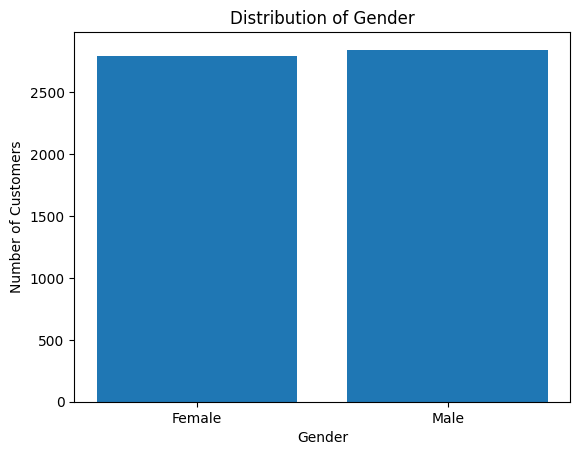

In [84]:
import matplotlib.pyplot as plt

counts = df_eda_imputed.group_by("gender").len()

plt.bar(counts["gender"], counts["len"])
plt.title("Distribution of Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

The dataset contains a nearly balanced distribution of genders, with approximately 49.5% female and 50.5% male customers. From a modeling perspective, this is beneficial because both categories are well represented in the dataset, reducing the risk of imbalance-related biases during training.

However, the inclusion of gender in predictive models raises important regulatory and ethical considerations.

Even if gender were found to be statistically associated with churn, using it as a feature in a decision-making system could introduce potential compliance risks. For example, churn prediction models are often used to identify customers with a high probability of leaving the service so that companies can offer targeted retention incentives such as discounts or promotional offers.

If gender were used as an input feature in such a system, it could indirectly influence which customers receive these benefits. In jurisdictions such as the European Union, regulations aimed at preventing discrimination may restrict or prohibit decision-making processes that treat customers differently based on protected characteristics, including gender.

For this reason, organizations often need to carefully evaluate whether sensitive attributes should be included in predictive models, even if they appear to improve model performance. In many practical scenarios, such variables are either excluded from the feature set or used only for fairness evaluation and monitoring, rather than as direct model inputs.

Sensitive attributes like gender may still be analyzed during model evaluation to monitor potential bias or disparate impact across demographic groups.

**Conclusion**

Due to the sensitive nature of the `gender` variable, it will be excluded from the feature set used for model training.

### SeniorCitizen

Whether the customer is a senior citizen or not (1, 0)

In [85]:
counts = df_eda_imputed["SeniorCitizen"].value_counts()
counts.with_columns(
    (pl.col("count") / df_eda_imputed.height * 100).alias("percentage")
)

SeniorCitizen,count,percentage
i64,u32,f64
0,4732,83.99006
1,902,16.00994


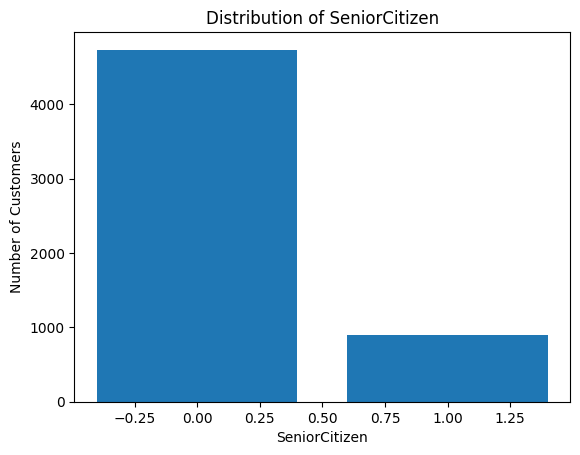

In [86]:
import matplotlib.pyplot as plt

counts = df_eda_imputed.group_by("SeniorCitizen").len()

plt.bar(counts["SeniorCitizen"], counts["len"])
plt.title("Distribution of SeniorCitizen")
plt.xlabel("SeniorCitizen")
plt.ylabel("Number of Customers")
plt.show()

The dataset contains approximately 16% senior citizens. While age can sometimes raise fairness or regulatory considerations, it is commonly used in many industries as a basis for targeted offers, such as senior discounts or age-based service plans.

In the context of this project, which focuses on the telecommunications industry, the use of age-related information does not present the same level of regulatory concern as it might in highly regulated domains such as healthcare, finance, banking, insurance, or employment. For this reason, the SeniorCitizen variable will be retained as a potential predictive feature.

Additionally, as mentioned in the project overview, the values in this variable are currently encoded as:
```
1 = Yes
0 = No
```
To maintain consistency with the rest of the dataset—where most categorical variables use "Yes" and "No" values—the variable will be re-encoded accordingly.

In [87]:
df_eda_imputed = df_eda_imputed.with_columns(
    pl.when(pl.col("SeniorCitizen") == 1)
    .then(pl.lit("Yes"))
    .otherwise(pl.lit("No"))
    .alias("SeniorCitizenRelevel")
)

counts = df_eda_imputed["SeniorCitizenRelevel"].value_counts()
counts.with_columns(
    (pl.col("count") / df_eda_imputed.height * 100).alias("percentage")
)

SeniorCitizenRelevel,count,percentage
str,u32,f64
"""Yes""",902,16.00994
"""No""",4732,83.99006


### Partner

Whether the customer has a partner or not (Yes, No)

In [88]:
counts = df_eda_imputed["Partner"].value_counts()
counts.with_columns(
    (pl.col("count") / df_eda_imputed.height * 100).alias("percentage")
)

Partner,count,percentage
str,u32,f64
"""No""",2916,51.757188
"""Yes""",2718,48.242812


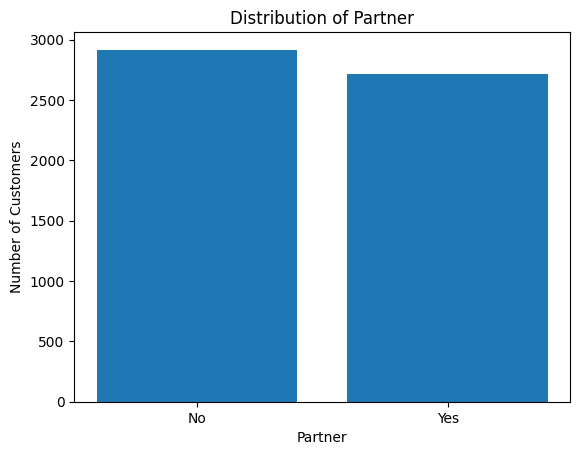

In [89]:
import matplotlib.pyplot as plt

counts = df_eda_imputed.group_by("Partner").len()

plt.bar(counts["Partner"], counts["len"])
plt.title("Distribution of Partner")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")
plt.show()

The dataset shows a relatively balanced distribution between customers with partners and those without partners. Both categories are well represented, which is beneficial from a modeling perspective because the model will have sufficient observations for each group.

From a behavioral perspective, partnership status may influence customer churn. Customers with partners may have different service usage patterns or financial commitments, which could affect their likelihood of remaining with the service.

This variable may therefore provide useful information when analyzing the relationship between household characteristics and churn behavior, which will be explored further in later sections.

### Dependents

Whether the customer has dependents or not (Yes, No)

In [90]:
counts = df_eda_imputed["Dependents"].value_counts()
counts.with_columns(
    (pl.col("count") / df_eda_imputed.height * 100).alias("percentage")
)

Dependents,count,percentage
str,u32,f64
"""No""",3959,70.269791
"""Yes""",1675,29.730209


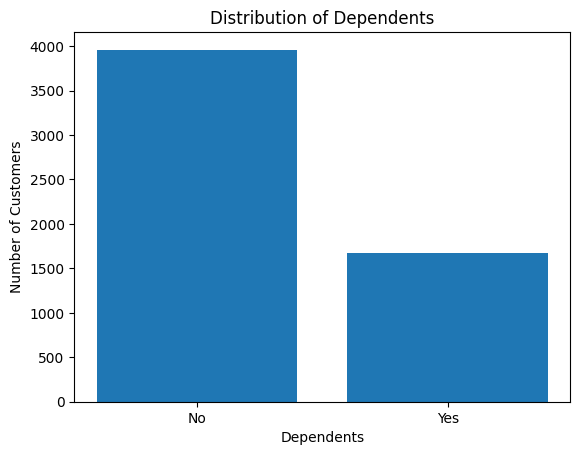

In [91]:
import matplotlib.pyplot as plt

counts = df_eda_imputed.group_by("Dependents").len()

plt.bar(counts["Dependents"], counts["len"])
plt.title("Distribution of Dependents")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")
plt.show()

The dataset shows that approximately 30% of customers have dependents, while the majority of customers do not.

This imbalance suggests that customers without dependents represent the dominant group in the dataset. Household composition may influence service usage patterns and financial priorities, which could potentially affect customer retention behavior.

The relationship between having dependents and churn will be explored further in later sections when analyzing variables in relation to the target variable.

### Tenure

Number of months the customer has stayed with the company.

In [92]:
df_eda_imputed["tenure"].describe()

statistic,value
str,f64
"""count""",5634.0
"""null_count""",0.0
"""mean""",32.270146
"""std""",24.595513
"""min""",0.0
"""25%""",9.0
"""50%""",29.0
"""75%""",55.0
"""max""",72.0


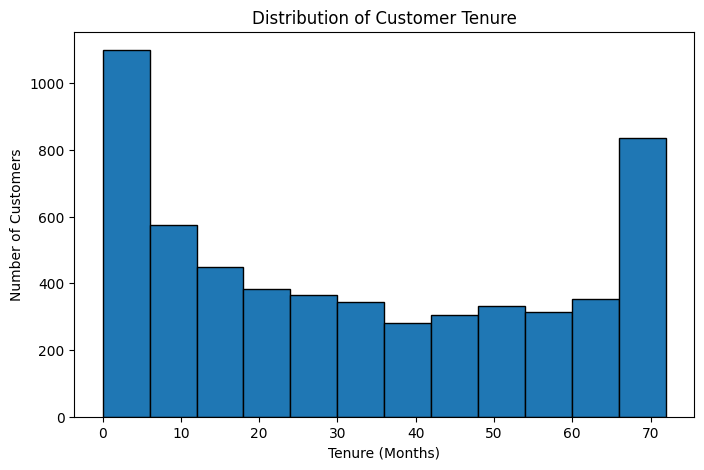

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
# 12 bins because tenure is in months and the maximum tenure is 72 months, so 12 bins gives us a nice overview of the distribution without being too granular.
plt.hist(df_eda_imputed["tenure"], bins=12, edgecolor="black")

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

e previously examined tenure while investigating the missing values in TotalCharges, so the presence of customers with tenure = 0 is already understood and does not provide new insight here.

However, the overall distribution of tenure is still interesting in the context of customer churn.

More than half of the customers have a tenure shorter than approximately 30 months (around 2.5 years), even though the maximum tenure in the dataset is 72 months (6 years).

If we assume that:

 - customer acquisition is relatively constant over time, and

 - the probability of churn does not depend on tenure,

then we would expect the number of customers to decrease gradually as tenure increases, roughly resembling an exponential decay distribution.

Instead, the histogram shows a different pattern:

 - A large concentration of customers with tenure below one year

 - A relatively stable number of customers across the middle tenure range

 - A noticeable spike in the final tenure segment

This pattern suggests that tenure may be strongly related to churn behavior, even before explicitly comparing it with the churn variable.

**Investigating the 72-Month Tenure Spike**

The last bin in the histogram contains a large number of customers with tenure close to the maximum value of 72 months. To investigate this further, we can examine how many customers have this exact tenure value.

In [94]:
print(f"Number of customers with 72 months of tenure: {df_eda_imputed.filter(pl.col("tenure")==72).height}")
print(f"Percentage of customers with 72 months of tenure: {df_eda_imputed.filter(pl.col("tenure")==72).height / df_eda_imputed.height * 100:.2f}%")

Number of customers with 72 months of tenure: 297
Percentage of customers with 72 months of tenure: 5.27%


The result shows that 297 customers (slightly above 5% of the dataset) have a tenure of exactly 72 months.

To further understand the distribution of tenure values, we can look at the most frequent tenure levels:

In [95]:
df_eda_imputed["tenure"].value_counts().with_columns(
    (pl.col("count") / df_eda_imputed.height * 100).alias("percentage")
).sort("count", descending=True).head(5)

tenure,count,percentage
i64,u32,f64
1,495,8.785942
72,297,5.271565
2,194,3.443379
3,153,2.715655
71,143,2.538161


This table shows that the most common tenure values are:

 - 1 month, which is expected since new customers have had little opportunity to churn

 - 72 months, representing the maximum tenure in the dataset

The concentration of customers at exactly 72 months suggests the presence of censoring or truncation in the data. This could occur for several reasons, such as:

 - a system migration where older customers were assigned a maximum tenure value

 - a reporting cutoff where tenure was capped at six years

 - limitations in the historical data used to construct the dataset

Regardless of the exact cause, this observation indicates that a significant portion of customers have reached the maximum observable tenure in the dataset.

**Interpretation**

The distribution of tenure strongly suggests that customer longevity is an important factor in churn behavior. Customers with very short tenure appear to be more numerous, while a smaller but stable group of long-term customers has remained with the company for several years.

This makes tenure a promising feature for predicting churn and an important variable to examine further when analyzing the relationship between features and the target variable.

### PhoneService

Whether the customer has a phone service or not (Yes, No)

In [96]:
counts = df_eda_imputed["PhoneService"].value_counts()
counts.with_columns(
    (pl.col("count") / df_eda_imputed.height * 100).alias("percentage")
)

PhoneService,count,percentage
str,u32,f64
"""No""",521,9.247426
"""Yes""",5113,90.752574


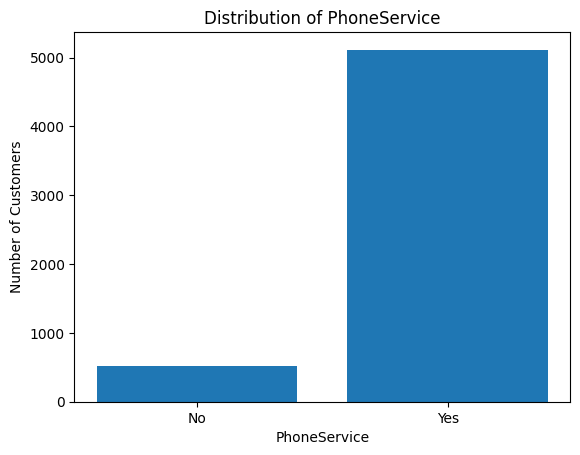

In [97]:
import matplotlib.pyplot as plt

counts = df_eda_imputed.group_by("PhoneService").len()

plt.bar(counts["PhoneService"], counts["len"])
plt.title("Distribution of PhoneService")
plt.xlabel("PhoneService")
plt.ylabel("Number of Customers")
plt.show()

The dataset shows that the vast majority of customers have phone service provided by the company. This is expected, given that the dataset represents a telecommunications provider. Only approximately 9.3% of customers do not use phone service.

Although the dataset is somewhat imbalanced with respect to this variable, the minority group is still large enough to be represented during model training and evaluation. However, when creating training and test splits, it is still good practice to ensure that the distribution of categorical variables remains consistent across the splits.

In practice, this can be addressed by using stratified sampling, where the proportions of key categorical variables are preserved between the training and testing datasets. This helps ensure that the model is evaluated on data that reflects the overall distribution of the dataset.

### Multiple Lines

Whether the customer has multiple lines or not (Yes, No, No phone service)

In [98]:
counts = df_eda_imputed["MultipleLines"].value_counts()
counts.with_columns(
    (pl.col("count") / df_eda_imputed.height * 100).alias("percentage")
    )

MultipleLines,count,percentage
str,u32,f64
"""No""",2723,48.331558
"""No phone service""",521,9.247426
"""Yes""",2390,42.421015


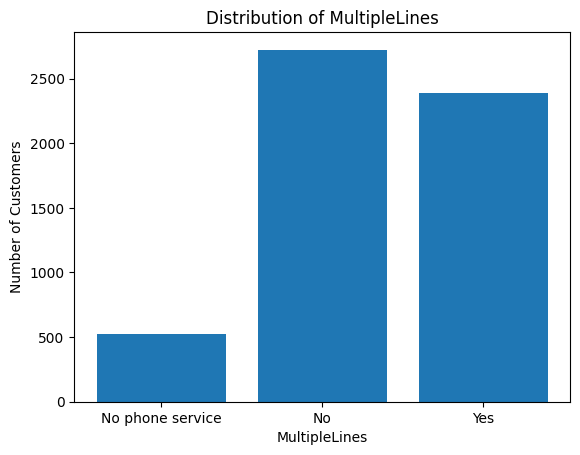

In [99]:
import matplotlib.pyplot as plt

counts = df_eda_imputed.group_by("MultipleLines").len()

plt.bar(counts["MultipleLines"], counts["len"])
plt.title("Distribution of MultipleLines")
plt.xlabel("MultipleLines")
plt.ylabel("Number of Customers")
plt.show()

The distribution of this variable shows a relatively even split between `"Yes"` and `"No"`. However, it also includes the category "No phone service", which corresponds to customers who do not have phone service at all.

When examining `MultipleLines` together with the `PhoneService` variable, it becomes clear that all information contained in `PhoneService` is already encoded within `MultipleLines`. Specifically:
```
MultipleLines = "No phone service" => PhoneService = "No"
```

this means that `MultipleLines` effectively represents three states:

 - No phone service

 - Phone service with a single line

 - Phone service with multiple lines

Because of this structure, MultipleLines contains strictly more information than the PhoneService variable.

Including both variables in the same model would therefore introduce redundant information. While many machine learning algorithms can technically handle redundant features, it may lead to issues such as multicollinearity or unnecessary feature duplication.

For this reason, it is generally preferable to include only one of these variables in the model. Since MultipleLines provides a more detailed representation of phone service usage, it is the more informative candidate for modeling purposes.

The final decision will depend on whether the number of phone lines appears to have a meaningful relationship with churn in later analysis.

### InternetService

Customer’s internet service provider (DSL, Fiber optic, No)

In [100]:
counts = df_eda_imputed["InternetService"].value_counts()
counts.with_columns(
    (pl.col("count") / df_eda_imputed.height * 100).alias("percentage")
)

InternetService,count,percentage
str,u32,f64
"""Fiber optic""",2480,44.018459
"""DSL""",1929,34.238552
"""No""",1225,21.742989


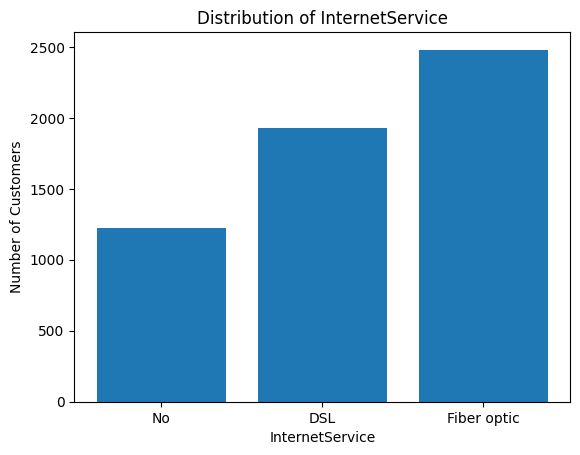

In [101]:
import matplotlib.pyplot as plt

counts = df_eda_imputed.group_by("InternetService").len()

plt.bar(counts["InternetService"], counts["len"])
plt.title("Distribution of InternetService")
plt.xlabel("InternetService")
plt.ylabel("Number of Customers")
plt.show()

The InternetService variable shows that all three categories are well represented in the dataset. The smallest group is customers without internet service (No), representing approximately 21% of the dataset, while the largest group consists of customers using Fiber optic connections, accounting for about 44%. The remaining customers use DSL internet service.

The presence of all three categories in substantial proportions is beneficial for modeling, as it allows the model to learn patterns associated with different types of internet service. Differences in service type may also reflect variations in service quality, pricing, and usage patterns, which could potentially influence customer churn behavior.

The relationship between internet service type and churn will be examined further in later sections when analyzing variables in relation to the target variable.

### OnlineSecurity

Whether the customer has online security or not (Yes, No, No internet service)

In [102]:
counts = df_eda_imputed["OnlineSecurity"].value_counts()
counts.with_columns(
    (pl.col("count") / df_eda_imputed.height * 100).alias("percentage")
)

OnlineSecurity,count,percentage
str,u32,f64
"""No""",2787,49.467519
"""No internet service""",1225,21.742989
"""Yes""",1622,28.789492


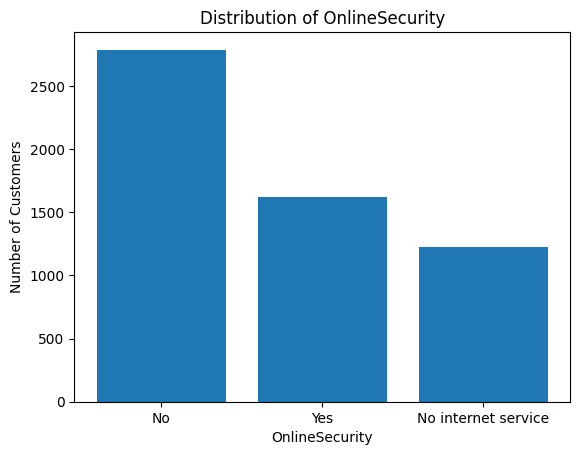

In [103]:
import matplotlib.pyplot as plt

counts = df_eda_imputed.group_by("OnlineSecurity").len()

plt.bar(counts["OnlineSecurity"], counts["len"])
plt.title("Distribution of OnlineSecurity")
plt.xlabel("OnlineSecurity")
plt.ylabel("Number of Customers")
plt.show()

Once again we encounter a variable that is not independent from another feature in the dataset. In this case, the relationship exists between `OnlineSecurity` and `InternetService`.

The `InternetService` variable indicates whether a customer has `DSL`, `Fiber optic`, or `no internet service`. The `OnlineSecurity` variable further expands on this information by indicating whether customers who have internet service have also subscribed to an additional online security service.

Because customers without internet service cannot use online security, the variable also contains the category:
```
No internet service
```
This creates a hierarchical relationship between the variables `InternetService` and `OnlineSecurity`

The `OnlineSecurity` variable therefore contains more detailed information about service usage, while still depending on the presence of internet service.

Unlike the earlier case with `PhoneService` and `MultipleLines`, where one variable completely contained the information of the other, both variables here provide complementary information:

`InternetService` describes the type of internet connection

`OnlineSecurity` describes whether an additional service is subscribed to

For this reason, both variables may still provide useful information for predictive modeling.


### OnlineBackup

Whether the customer has online backup or not (Yes, No, No internet service)

In [104]:
counts = df_eda_imputed["OnlineBackup"].value_counts()
counts.with_columns(
    (pl.col("count") / df_eda_imputed.height * 100).alias("percentage")
)

OnlineBackup,count,percentage
str,u32,f64
"""Yes""",1938,34.398296
"""No internet service""",1225,21.742989
"""No""",2471,43.858715


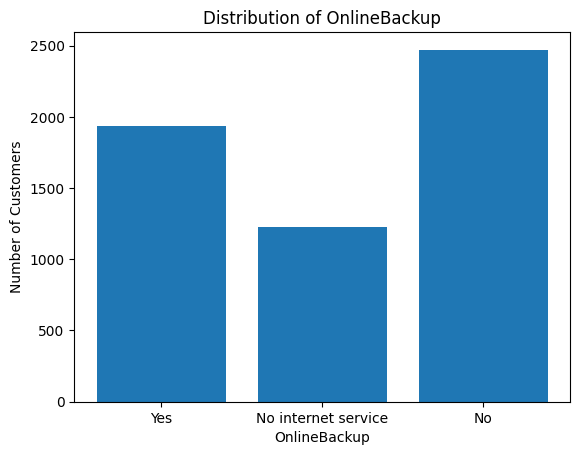

In [105]:
import matplotlib.pyplot as plt

counts = df_eda_imputed.group_by("OnlineBackup").len()

plt.bar(counts["OnlineBackup"], counts["len"])
plt.title("Distribution of OnlineBackup")
plt.xlabel("OnlineBackup")
plt.ylabel("Number of Customers")
plt.show()

The distribution of `OnlineBackup` follows the same structural pattern observed with `OnlineSecurity`. Customers without internet service are categorized as `No internet service`, reflecting the dependency between this variable and `InternetService`.

This variable therefore represents an additional internet-related service that can only be subscribed to by customers who already have internet access.

### DeviceProtection

Whether the customer has device protection or not (Yes, No, No internet service)

In [106]:
counts = df_eda_imputed["DeviceProtection"].value_counts()
counts.with_columns(
    (pl.col("count") / df_eda_imputed.height * 100).alias("percentage")
)

DeviceProtection,count,percentage
str,u32,f64
"""Yes""",1946,34.540291
"""No internet service""",1225,21.742989
"""No""",2463,43.71672


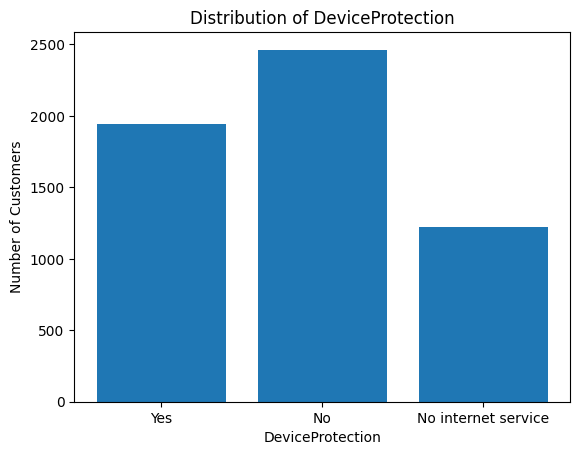

In [107]:
import matplotlib.pyplot as plt

counts = df_eda_imputed.group_by("DeviceProtection").len()

plt.bar(counts["DeviceProtection"], counts["len"])
plt.title("Distribution of DeviceProtection")
plt.xlabel("DeviceProtection")
plt.ylabel("Number of Customers")
plt.show()

The DeviceProtection variable follows the same structural pattern observed with `OnlineSecurity` and `OnlineBackup`. Customers who do not have internet service are categorized as `No internet service`, reflecting the dependency between this variable and `InternetService`.

This variable represents another additional service that can only be used by customers with an active internet connection, indicating whether a customer has subscribed to device protection for their equipment.

### TechSupport

Whether the customer has tech support or not (Yes, No, No internet service)

In [108]:
counts = df_eda_imputed["TechSupport"].value_counts()
counts.with_columns(
    (pl.col("count") / df_eda_imputed.height * 100).alias("percentage")
)

TechSupport,count,percentage
str,u32,f64
"""No""",2783,49.396521
"""No internet service""",1225,21.742989
"""Yes""",1626,28.86049


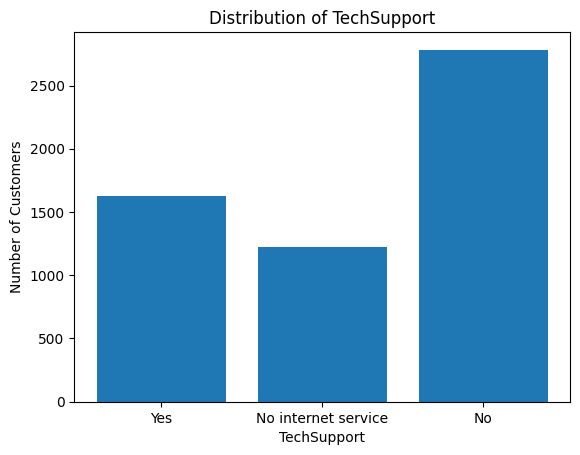

In [109]:
import matplotlib.pyplot as plt

counts = df_eda_imputed.group_by("TechSupport").len()

plt.bar(counts["TechSupport"], counts["len"])
plt.title("Distribution of TechSupport")
plt.xlabel("TechSupport")
plt.ylabel("Number of Customers")
plt.show()

The `TechSupport` variable follows the same structural relationship with `InternetService` as observed for the other internet-related services. Customers who do not have internet service are categorized as No internet service, reflecting the dependency between this variable and the presence of an internet connection.

This variable indicates whether a customer has subscribed to technical support services, which are available only to customers who already have internet service.

### StreamingTV and StreamingMovies

- StreamingTV: Whether the customer has streaming TV or not (Yes, No, No internet service) 
- StreamingMovies: Whether the customer has streaming movies or not (Yes, No, No internet service)

In [110]:
counts = df_eda_imputed["StreamingTV"].value_counts()
counts.with_columns(
    (pl.col("count") / df_eda_imputed.height * 100).alias("percentage")
)

StreamingTV,count,percentage
str,u32,f64
"""No internet service""",1225,21.742989
"""Yes""",2171,38.533901
"""No""",2238,39.72311


In [111]:
counts = df_eda_imputed["StreamingMovies"].value_counts()
counts.with_columns(
    (pl.col("count") / df_eda_imputed.height * 100).alias("percentage")
)

StreamingMovies,count,percentage
str,u32,f64
"""No""",2226,39.510117
"""Yes""",2183,38.746894
"""No internet service""",1225,21.742989


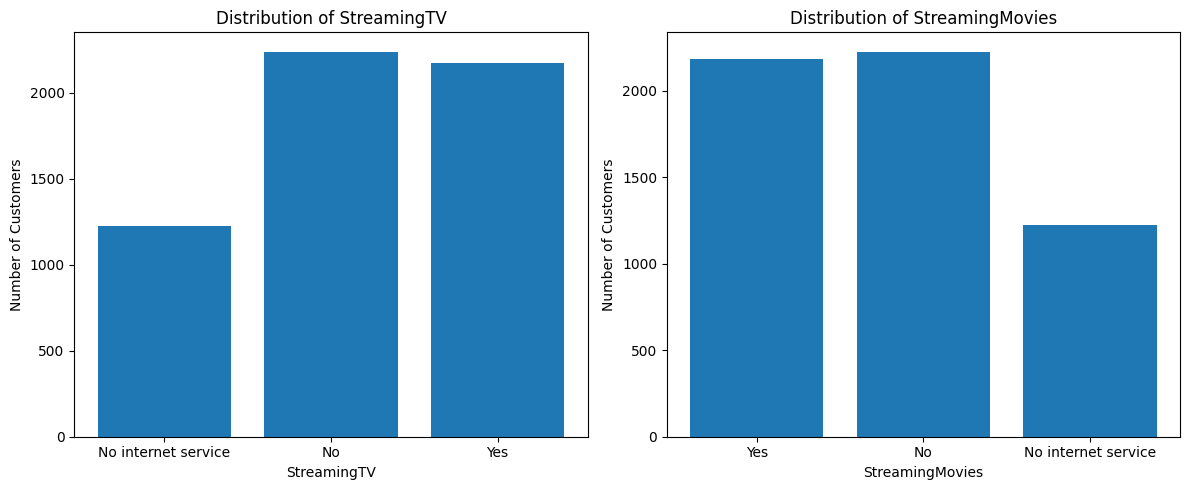

In [112]:
import matplotlib.pyplot as plt

tv_counts = df_eda_imputed.group_by("StreamingTV").len()
movie_counts = df_eda_imputed.group_by("StreamingMovies").len()

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Streaming TV
axes[0].bar(tv_counts["StreamingTV"], tv_counts["len"])
axes[0].set_title("Distribution of StreamingTV")
axes[0].set_xlabel("StreamingTV")
axes[0].set_ylabel("Number of Customers")

# Streaming Movies
axes[1].bar(movie_counts["StreamingMovies"], movie_counts["len"])
axes[1].set_title("Distribution of StreamingMovies")
axes[1].set_xlabel("StreamingMovies")
axes[1].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

The variables `StreamingTV` and `StreamingMovies` follow the same structural pattern observed for the other internet-related services. Customers without internet service are categorized as `No internet service`, reflecting the dependency between these variables and `InternetService`.

From the distributions shown above, we can see that both streaming services are relatively evenly split between customers who have subscribed to them and those who have not. This suggests that streaming services are a common but not universal add-on, with a substantial portion of customers choosing not to use these features even when internet service is available.

Because streaming services represent optional value-added services, they may reflect differences in customer usage behavior and engagement with the company's offerings. Customers who subscribe to multiple services may have a stronger relationship with the provider, which could potentially influence their likelihood of remaining with the company.

The relationship between streaming services and churn will therefore be examined more closely in later sections when analyzing the dataset in relation to the target variable.

### Summary of Internet-Related Services

Several variables in the dataset describe additional services that are dependent on the presence of internet service. These include:

 - `OnlineSecurity`

 - `OnlineBackup`

 - `DeviceProtection`

 - `TechSupport`

 - `StreamingTV`

 - `StreamingMovies`

All of these variables share a common structural pattern: customers without internet service are categorized as No internet service, reflecting the fact that these services can only be subscribed to by customers who already have an active internet connection.

This creates a hierarchical relationship within the dataset:

```
InternetService -> Optional Internet Services
```

The additional service variables therefore represent optional add-ons to the base internet service, expanding the set of services a customer may subscribe to.

From an analytical perspective, these variables likely capture customer engagement with the company's ecosystem of services. Customers who subscribe to multiple services may have a stronger relationship with the provider, while customers who only use basic services may have fewer switching barriers.

Because of this structure, it may also be useful later to explore aggregate measures of service usage, such as the total number of subscribed services per customer.

For now, we note that these variables are structurally related and should be interpreted together when analyzing customer behavior.

### Contracts

The contract term of the customer (Month-to-month, One year, Two year)

In [113]:
counts = df_eda_imputed["Contract"].value_counts()
counts.with_columns(
    (pl.col("count") / df_eda_imputed.height * 100).alias("percentage")
)

Contract,count,percentage
str,u32,f64
"""One year""",1173,20.820021
"""Month-to-month""",3117,55.324814
"""Two year""",1344,23.855165


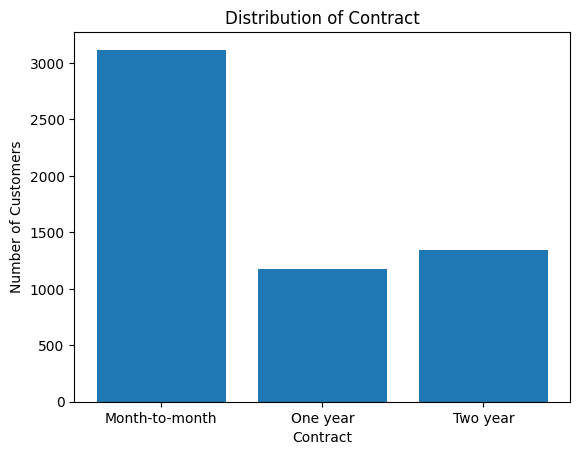

In [114]:
import matplotlib.pyplot as plt

counts = df_eda_imputed.group_by("Contract").len()

plt.bar(counts["Contract"], counts["len"])
plt.title("Distribution of Contract")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")
plt.show()

The majority of customers in the dataset have a `Month-to-month` contract, while smaller portions of customers are subscribed to `one-year` or `two-year` contracts.

From a business perspective, this distribution is meaningful. Customers who are tied to longer-term contracts typically face higher switching costs, such as contractual obligations or potential penalties for early termination. As a result, they may be less likely to leave the service compared to customers on flexible month-to-month plans.

Customers with `Month-to-month` contracts, on the other hand, have significantly lower barriers to switching providers, which could make them more likely to churn.

Because of these factors, the contract type variable is likely to play an important role in predicting customer churn, and its relationship with the target variable will be examined in more detail later in the analysis.

### PaperlessBilling

Whether the customer has paperless billing or not (Yes, No)

In [115]:
counts = df_eda_imputed["PaperlessBilling"].value_counts()
counts.with_columns(
    (pl.col("count") / df_eda_imputed.height * 100).alias("percentage")
)

PaperlessBilling,count,percentage
str,u32,f64
"""Yes""",3333,59.158679
"""No""",2301,40.841321


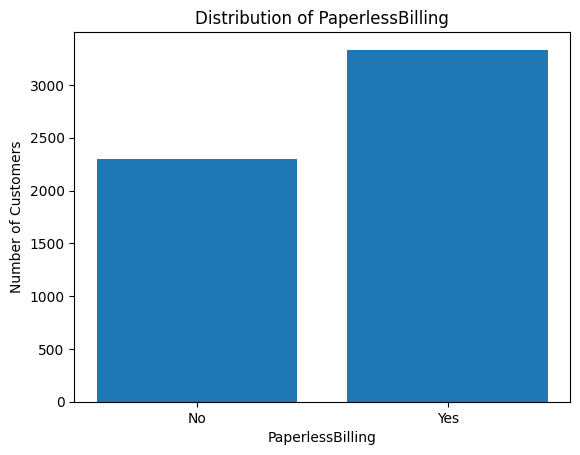

In [116]:
import matplotlib.pyplot as plt

counts = df_eda_imputed.group_by("PaperlessBilling").len()

plt.bar(counts["PaperlessBilling"], counts["len"])
plt.title("Distribution of PaperlessBilling")
plt.xlabel("PaperlessBilling")
plt.ylabel("Number of Customers")
plt.show()

Although there is no clear causal mechanism linking paperless billing to churn, it may act as a proxy for payment behavior or customer engagement. Therefore, it is still worth investigating whether any statistical relationship exists.

### PaymentMethod

The customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card)

In [117]:
counts = df_eda_imputed["PaymentMethod"].value_counts()
counts.with_columns(
    (pl.col("count") / df_eda_imputed.height * 100).alias("percentage")
)

PaymentMethod,count,percentage
str,u32,f64
"""Bank transfer (automatic)""",1244,22.080227
"""Electronic check""",1884,33.43983
"""Mailed check""",1286,22.825701
"""Credit card (automatic)""",1220,21.654242


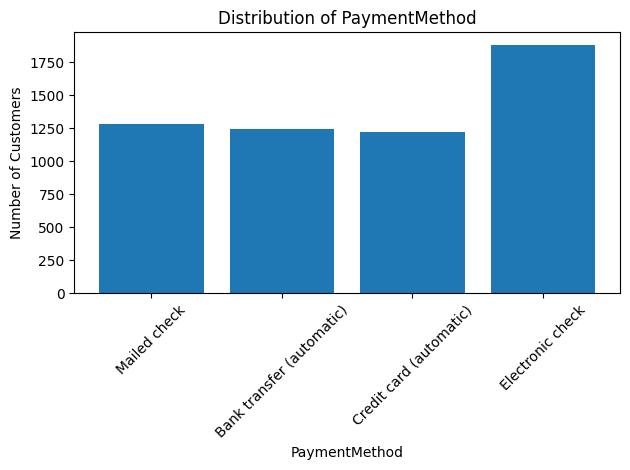

In [118]:
import matplotlib.pyplot as plt

counts = df_eda_imputed.group_by("PaymentMethod").len()

plt.bar(counts["PaymentMethod"], counts["len"])
plt.title("Distribution of PaymentMethod")
plt.xlabel("PaymentMethod")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)   # rotate labels
plt.tight_layout()        # prevents label cutoff

plt.show()

Payment method is unlikely to be a direct causal factor of churn; however, it may capture behavioral differences in how customers interact with billing processes. Automatic payment methods generally simplify recurring payments, whereas manual methods may introduce additional effort or risk of missed payments. As a result, payment method may indirectly correlate with churn and should be considered as a potential explanatory feature in the analysis.

### MonthlyCharges

The amount charged to the customer monthly

In [119]:
df_eda_imputed["MonthlyCharges"].describe()

statistic,value
str,f64
"""count""",5634.0
"""null_count""",0.0
"""mean""",64.870367
"""std""",30.097198
"""min""",18.25
"""25%""",35.65
"""50%""",70.45
"""75%""",89.9
"""max""",118.75


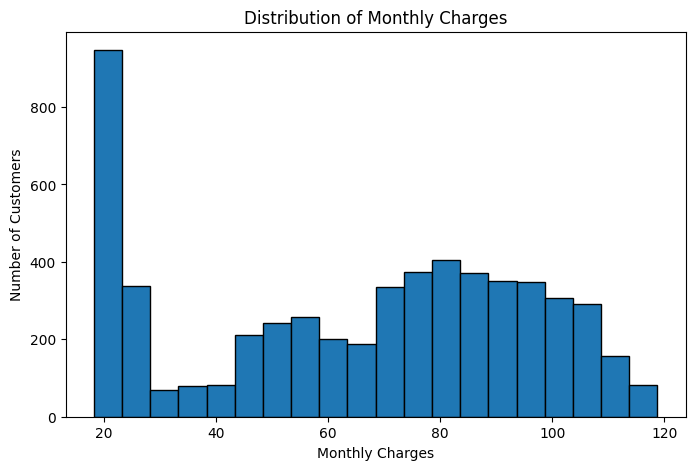

In [120]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_eda_imputed["MonthlyCharges"], bins=20, edgecolor="black")

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

In [121]:
df_eda_imputed["MonthlyCharges"].value_counts().with_columns(
    (pl.col("count") / df_eda_imputed.height * 100).alias("percentage")
).sort("count", descending=True).head(5)

MonthlyCharges,count,percentage
f64,u32,f64
20.05,43,0.763223
19.85,38,0.674476
19.9,36,0.638978
20.0,36,0.638978
19.7,35,0.621228


The distribution of monthly charges shows that roughly one quarter of customers pay around `20 units (USD/EUR)`, suggesting the presence of a common baseline or lower-tier service plan. The remaining customers are more evenly distributed across higher price ranges, indicating a variety of service packages and add-ons. This variation in monthly charges may reflect differences in service usage and subscription levels, which could potentially influence churn behavior.

### TotalCharges

The total amount charged to the customer

In [122]:
df_eda_imputed["TotalCharges"].describe()

statistic,value
str,f64
"""count""",5634.0
"""null_count""",0.0
"""mean""",2276.854553
"""std""",2268.478598
"""min""",0.0
"""25%""",389.1
"""50%""",1397.65
"""75%""",3767.4
"""max""",8684.8


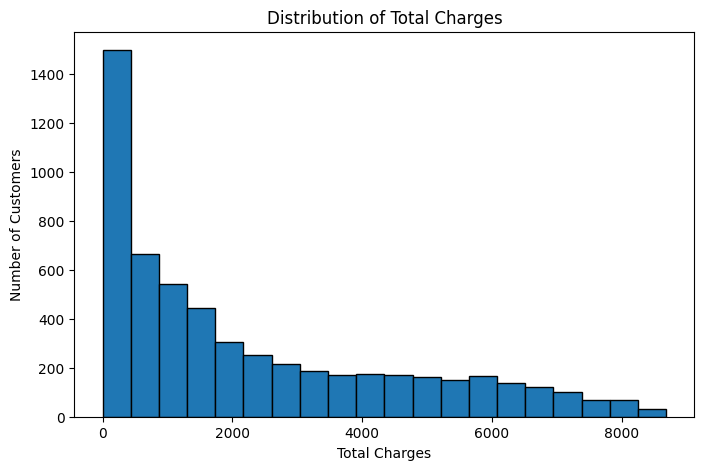

In [123]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_eda_imputed["TotalCharges"], bins=20, edgecolor="black")

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.show()

The distribution of total charges appears to follow an exponential-like pattern, with a large number of customers having relatively low total charges and progressively fewer customers with higher accumulated charges. This pattern likely reflects the underlying tenure distribution, as total charges are largely determined by how long a customer has been subscribed to the service. Therefore, total charges will be considered when modeling churn, and its relationship with tenure should be examined.

### Churn

Whether the customer churned or not (Yes or No)

In [124]:
counts = df_eda_imputed["Churn"].value_counts()
counts.with_columns(
    (pl.col("count") / df_eda_imputed.height * 100).alias("percentage")
)

Churn,count,percentage
str,u32,f64
"""Yes""",1495,26.535321
"""No""",4139,73.464679


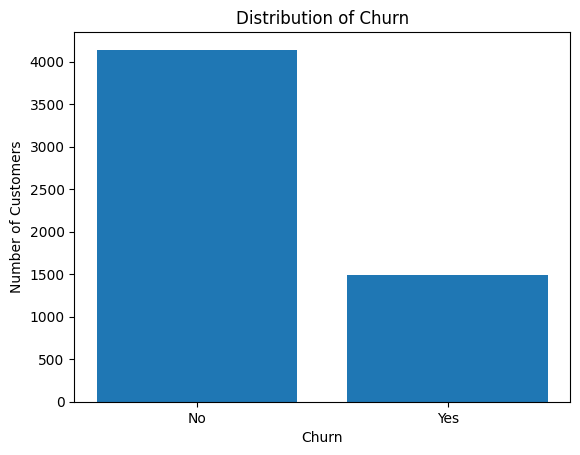

In [125]:
import matplotlib.pyplot as plt

counts = df_eda_imputed.group_by("Churn").len()

plt.bar(counts["Churn"], counts["len"])
plt.title("Distribution of Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

The distribution of the churn variable shows the proportion of customers who have left the service compared to those who have remained. As churn represents the target variable of the analysis, it will not be used as a predictor in the modeling process. Instead, it serves as the outcome that the models will attempt to explain and predict based on other customer characteristics.

### Summary and key findings of variable exploration

The exploratory analysis of individual variables provides several important insights into the structure of the dataset and the potential usefulness of different features for churn modeling.

First, several variables were identified as unsuitable for predictive modeling. The `CustomerID` variable serves purely as a unique identifier and does not contain meaningful behavioral information, and therefore it will be excluded from the feature set. The `gender` variable, while balanced in the dataset, represents a sensitive attribute and will also be excluded from modeling to avoid potential ethical and regulatory concerns.

The dataset contains a mixture of demographic, service-related, and financial variables. Demographic features such as `SeniorCitizen`, `Partner`, and `Dependents` describe household characteristics that may influence customer behavior and service usage. These variables are generally well represented in the dataset and may provide useful context when analyzing churn patterns.

Several variables describe the services subscribed to by each customer. In particular, a group of internet-related variables (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, and `StreamingMovies`) form a hierarchical structure that depends on the presence of internet service. These variables represent optional add-on services and may serve as indicators of customer engagement with the provider's service ecosystem.

A similar structural relationship was observed between `PhoneService` and `MultipleLines`, where the `MultipleLines` variable already encodes whether a customer has phone service. Because `MultipleLines` provides a more detailed representation of phone usage, it may be preferable to use this variable instead of `PhoneService` when constructing predictive models.

Contract and billing-related variables (`Contract`, `PaperlessBilling`, and `PaymentMethod`) capture aspects of the customer's relationship with the provider. In particular, contract length may influence switching costs, while payment method and billing preferences may reflect differences in payment behavior or customer engagement.

The numerical variables `MonthlyCharges`, `TotalCharges`, and `tenure` describe the financial and time aspects of the customer relationship. The distribution of `tenure` suggests that a large proportion of customers are relatively new, while a smaller group of long-term customers has remained with the company for several years. Additionally, the distribution of `TotalCharges` closely follows the `tenure` distribution, reflecting the cumulative nature of this variable.

Overall, the dataset contains a rich combination of demographic, service usage, contractual, and financial variables that may help explain differences in customer churn behavior.

In the following section, we will begin examining how these variables relate directly to the churn outcome.

### Selected Variables for Further Analysis

Based on the exploratory analysis above, a subset of variables will be carried forward to the next stage of the analysis, where their relationship with the churn outcome will be examined.

Some variables are excluded at this stage. The CustomerID variable serves only as a unique identifier and does not contain meaningful information for predictive modeling. The gender variable is excluded due to its sensitive nature and potential regulatory implications when used in automated decision-making systems. Additionally, the PhoneService variable is redundant because its information is already captured within the MultipleLines variable.

The remaining variables retained for further analysis include:

 - `SeniorCitizen`
 - `Partner`
 - `Dependents`
 - `tenure`
 - `MultipleLines`
 - `InternetService`
 - `OnlineSecurity`
 - `OnlineBackup`
 - `DeviceProtection`
 - `TechSupport`
 - `StreamingTV`
 - `StreamingMovies`
 - `Contract`
 - `PaperlessBilling`
 - `PaymentMethod`
 - `MonthlyCharges`
 - `TotalCharges`

These variables capture several dimensions of customer behavior, including demographic characteristics, service usage patterns, contractual commitments, billing behavior, and financial aspects of the customer relationship.

Certain structural relationships identified during exploratory analysis will be considered in later stages of modeling. In particular:

 - `TotalCharges` is closely related to `tenure`, as it represents the cumulative amount billed over time.

 - Several internet-related services depend on the presence of `InternetService`.

These relationships will be examined further to determine whether feature transformations or dimensionality reduction techniques may be appropriate.

In the next section, we will analyze how each of these variables relates to the churn outcome.

In [126]:
selected_columns = [
    "SeniorCitizenRelevel",
    "Partner",
    "Dependents",
    "tenure",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "MonthlyCharges",
    "TotalCharges",
    "Churn"
]

df_eda_selected = df_eda_imputed.select(selected_columns)

df_eda_selected.write_csv("./data/processed/03_eda_train_df_selected.csv")

## Relationship Between Customer Characteristics and Churn

In the previous section, we examined the structure and distribution of individual variables in the dataset. While this provided a solid understanding of the data, it did not address how these variables relate to the primary outcome of interest: customer churn.

In this section, we analyze how each variable relates to churn to identify patterns that may help explain why some customers leave the service while others remain.

For categorical variables, this involves comparing churn rates across categories. For continuous variables, we examine how their distributions differ between churned and non-churned customers.

This step serves as an initial assessment of feature relevance, helping identify variables that may be informative for predictive modeling.

It is important to note that this analysis considers each variable individually. Dependencies between predictors, such as correlations or multicollinearity, will be examined separately in later stages.

### Methodology for Analyzing Relationships with Churn

To systematically evaluate the relationship between features and customer churn, we apply different analytical approaches depending on the type of variable.

#### Categorical Variables

For categorical features, the relationship with churn is analyzed using:

 - Contingency tables (cross-tabulations) to observe differences in churn rates across categories

 - The Chi-Square test of independence, which evaluates whether the observed differences between categories are statistically significant

This approach allows us to identify whether churn behavior is associated with specific categories, such as contract types or service subscriptions.

#### Continuous Variables

For continuous variables, we combine visual analysis with statistical testing to capture multiple aspects of distributional differences between churned and non-churned customers.

**Visual Analysis**

For each continuous variable, we examine:

 - Box plots by churn group -> to compare medians, spread, and presence of outliers.

 - Histograms split by churn group -> to compare overall distribution shapes.

 - Binned analysis (churn rate by value ranges) -> to identify non-linear patterns such as threshold effects or U-shaped relationships.

These visualizations help reveal patterns that may not be captured by a single summary statistic.

**Statistical Testing**

To complement visual insights, we apply three statistical tests, each focusing on a different aspect of the distribution:

 - Welch’s t-test: 
    - evaluates differences in the mean between churned and non-churned customers.
    - appropriate when variances may differ between groups.

 - Mann–Whitney U test:
    - evaluates whether one group tends to have larger values than the other (rank-based comparison).
    - robust to non-normal distributions and outliers.

 - Brown–Forsythe test (a robust version of Levene’s test):
    - evaluates differences in variance (spread) between groups.
    - useful for detecting whether one group exhibits greater variability.

**Important Considerations**

Statistical significance does not necessarily imply a causal relationship.

In real-world datasets, observed relationships may arise due to underlying business processes or hidden variables. For example, a relationship between total spending and churn may reflect customer lifecycle dynamics rather than a direct causal mechanism (similar to how the presence of firefighters is associated with fire damage, without being its cause).

For this reason, statistical results are always interpreted together with domain knowledge and visual analysis, rather than in isolation.

**Connection to Predictive Modeling**

The statistical methods used here also relate directly to modeling techniques:

 - Mean differences align with linear models.

 - Rank-based differences align with threshold-based and tree models.

 - Variance and non-linear patterns motivate feature engineering and binning strategies.

Additionally, the Mann–Whitney U statistic has a direct connection to ROC AUC:

```
U / (n₁ · n₂) = AUC
```

This means that the test effectively measures the probability that a randomly selected churned customer has a higher (or lower) value than a randomly selected non-churned customer, aligning the Mann–Whitney U test with classification performance metrics such as ROC AUC.

Given the size of the dataset, statistical significance is interpreted alongside practical relevance, as large samples may yield statistically significant results even for small effect sizes.

#### Reusable comparison function for analysis

In [127]:
import polars as pl
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency


def analyze_categorical_vs_churn(
    df: pl.DataFrame,
    variable: str,
    target: str = "Churn",
    plot: bool = True,
):
    """
    Analyze relationship between a categorical variable and a binary churn target.

    Returns:
        contingency_df: frequency table
        rate_df: row-wise percentages
        stats: chi-square statistics
    """
    # frequency table in long format
    contingency_long = (
        df.group_by([variable, target])
        .len()
        .sort([variable, target])
    )

    # pivot to wide format
    contingency_df = (
        contingency_long
        .pivot(values="len", index=variable, on=target)
        .fill_null(0)
    )

    # make sure both churn classes exist
    for churn_class in ["No", "Yes"]:
        if churn_class not in contingency_df.columns:
            contingency_df = contingency_df.with_columns(
                pl.lit(0).alias(churn_class)
            )

    contingency_df = contingency_df.select([variable, "No", "Yes"])

    # row totals + churn rates
    rate_df = (
        contingency_df
        .with_columns(
            (pl.col("No") + pl.col("Yes")).alias("total")
        )
        .with_columns(
            (pl.col("No") / pl.col("total") * 100).round(2).alias("No_pct"),
            (pl.col("Yes") / pl.col("total") * 100).round(2).alias("Yes_pct"),
        )
    )

    # chi-square
    observed = contingency_df.select(["No", "Yes"]).to_numpy()
    chi2, p_value, dof, expected = chi2_contingency(observed)

    stats = {
        "chi2": chi2,
        "p_value": p_value,
        "degrees_of_freedom": dof,
        "expected_frequencies": expected,
    }


    print(f"\n===== Analysis for: {variable} =====\n")

    print("Bar chart:")
    
    # optional plot: 100% stacked bar chart
    if plot:
        x = rate_df[variable].to_list()
        no_vals = rate_df["No_pct"].to_list()
        yes_vals = rate_df["Yes_pct"].to_list()

        plt.figure(figsize=(8, 5))
        plt.bar(x, no_vals, label="No")
        plt.bar(x, yes_vals, bottom=no_vals, label="Yes")

        plt.title(f"Churn Rate by {variable}")
        plt.xlabel(variable)
        plt.ylabel("Percentage within category")
        plt.legend(title=target)
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

    print("Contingency table:")
    print(contingency_df)
    print("Rates:")
    print(rate_df)
    print("Chi-square statistic:", stats["chi2"])
    print("P-value:", stats["p_value"])
    print("\n==============================\n")

In [128]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

def analyze_continuous_vs_churn(df: pl.DataFrame, variable: str, target: str = "Churn", bins: int = 10):
    
    print(f"\n===== Analysis for: {variable} =====\n")
    
    # Split groups
    group_yes = df.filter(pl.col(target) == "Yes")[variable].drop_nulls().to_numpy()
    group_no = df.filter(pl.col(target) == "No")[variable].drop_nulls().to_numpy()
    
    # -----------------------
    # VISUALS
    # -----------------------
    
    plt.figure(figsize=(15, 4))
    
    # Boxplot
    plt.subplot(1, 3, 1)
    plt.boxplot([group_no, group_yes], tick_labels=["No Churn", "Churn"])
    plt.title(f"{variable} - Boxplot")
    
    # Histogram
    plt.subplot(1, 3, 2)
    plt.hist(group_no, bins=bins, alpha=0.5, label="No Churn")
    plt.hist(group_yes, bins=bins, alpha=0.5, label="Churn")
    plt.title(f"{variable} - Histogram")
    plt.legend()
    
    # Binned churn rate
    plt.subplot(1, 3, 3)

    values = df[variable].to_numpy()
    breaks = np.linspace(values.min(), values.max(), bins + 1)

    # Bin indices: 0, 1, 2, ..., bins-1
    bin_idx = np.digitize(values, breaks[1:-1], right=True)

    # Human-readable labels
    bin_labels = [
        f"({breaks[i]:.1f}, {breaks[i+1]:.1f}]"
        for i in range(len(breaks) - 1)
    ]

    # Directly construct the label for each row
    bin_label_values = [bin_labels[i] for i in bin_idx]

    df_binned = df.with_columns(
        pl.Series("bin_idx", bin_idx),
        pl.Series("bin", bin_label_values),
    )

    churn_rate = (
        df_binned
        .group_by(["bin_idx", "bin"])
        .agg(
            pl.len().alias("total"),
            (pl.col(target) == "Yes").sum().alias("churned")
        )
        .with_columns(
            (pl.col("churned") / pl.col("total") * 100).alias("churn_rate")
        )
        .sort("bin_idx")
    )

    plt.bar(range(len(churn_rate)), churn_rate["churn_rate"])
    plt.xticks(range(len(churn_rate)), churn_rate["bin"], rotation=45)
    plt.title("Churn Rate by Binned Values")
    plt.ylabel("Churn %")
    
    plt.tight_layout()
    plt.show()
    
    
    # -----------------------
    # STATISTICAL TESTS
    # -----------------------
    
    print("\n--- Statistical Tests ---\n")
    
    # Welch's t-test
    t_stat, t_p = stats.ttest_ind(group_yes, group_no, equal_var=False)
    print(f"Welch t-test:")
    print(f"  t-statistic = {t_stat:.4f}, p-value = {t_p:.4e}")
    
    # Mann–Whitney U
    u_stat, u_p = stats.mannwhitneyu(group_yes, group_no, alternative="two-sided")
    auc = u_stat / (len(group_yes) * len(group_no))
    
    print(f"\nMann-Whitney U test:")
    print(f"  U-statistic = {u_stat:.4f}, p-value = {u_p:.4e}")
    print(f"  AUC interpretation ≈ {auc:.4f}")
    
    # Brown–Forsythe (Levene centered at median)
    bf_stat, bf_p = stats.levene(group_yes, group_no, center="median")
    
    print(f"\nBrown-Forsythe test (variance):")
    print(f"  statistic = {bf_stat:.4f}, p-value = {bf_p:.4e}")
    
    print("\n==============================\n")

### Churn and SeniorCitizen

**Hypothesis**
Senior customers may exhibit lower churn rates compared to non-senior customers. One possible explanation is that switching telecom providers may represent a higher perceived effort or inconvenience, leading to greater customer retention in this group.

**Observation**


===== Analysis for: SeniorCitizenRelevel =====

Bar chart:


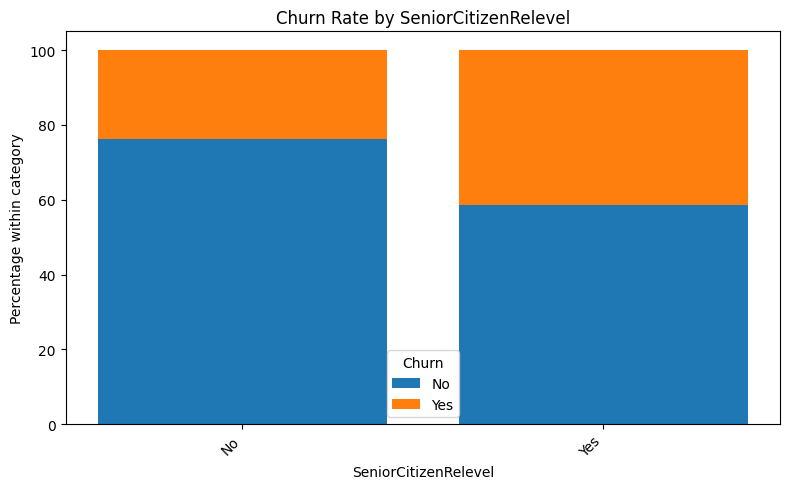

Contingency table:
shape: (2, 3)
┌──────────────────────┬──────┬──────┐
│ SeniorCitizenRelevel ┆ No   ┆ Yes  │
│ ---                  ┆ ---  ┆ ---  │
│ str                  ┆ u32  ┆ u32  │
╞══════════════════════╪══════╪══════╡
│ No                   ┆ 3611 ┆ 1121 │
│ Yes                  ┆ 528  ┆ 374  │
└──────────────────────┴──────┴──────┘
Rates:
shape: (2, 6)
┌──────────────────────┬──────┬──────┬───────┬────────┬─────────┐
│ SeniorCitizenRelevel ┆ No   ┆ Yes  ┆ total ┆ No_pct ┆ Yes_pct │
│ ---                  ┆ ---  ┆ ---  ┆ ---   ┆ ---    ┆ ---     │
│ str                  ┆ u32  ┆ u32  ┆ u32   ┆ f64    ┆ f64     │
╞══════════════════════╪══════╪══════╪═══════╪════════╪═════════╡
│ No                   ┆ 3611 ┆ 1121 ┆ 4732  ┆ 76.31  ┆ 23.69   │
│ Yes                  ┆ 528  ┆ 374  ┆ 902   ┆ 58.54  ┆ 41.46   │
└──────────────────────┴──────┴──────┴───────┴────────┴─────────┘
Chi-square statistic: 121.85772566994308
P-value: 2.479996003882641e-28




In [129]:
analyze_categorical_vs_churn(df_eda_selected, "SeniorCitizenRelevel")

The data does not support this expectation. 

From the contingency table, we observe:

- Non-senior customers:  
  - Churn rate ≈ **23.69%** (1121 out of 4732)

- Senior customers:  
  - Churn rate ≈ **41.64%** (374 out of 902)

This indicates that senior customers churn at a **substantially higher rate** than non-senior customers in this dataset.

The Chi-Square test of independence further confirms that this difference is statistically significant:

- χ² = 121.86
- p-value ≈ 2.48e-28  

This provides strong evidence that churn is associated with senior status.

**Interpretation**

The observed result contradicts the initial expectation. However, this does not imply that senior customers inherently churn more in general, but rather that in this dataset, age alone does not behave as initially anticipated.

The result should be interpreted cautiously, as it may reflect the specific characteristics of the dataset rather than a generalizable pattern. It also highlights the importance of validating intuitive expectations with data, as real-world customer behavior may differ from assumptions.

### Churn and Partner

**Hypothesis**

Customers with a partner may be less likely to churn compared to those without a partner. 

One possible explanation is that households with multiple individuals may subscribe to more services (e.g., internet, streaming, phone lines), increasing the overall dependency on the provider. This could lead to higher switching costs and lower likelihood of cancellation.

**Observation**


===== Analysis for: Partner =====

Bar chart:


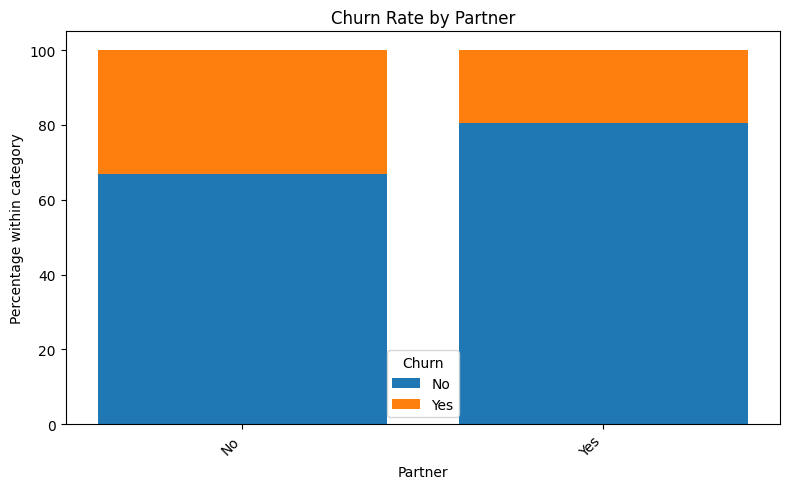

Contingency table:
shape: (2, 3)
┌─────────┬──────┬─────┐
│ Partner ┆ No   ┆ Yes │
│ ---     ┆ ---  ┆ --- │
│ str     ┆ u32  ┆ u32 │
╞═════════╪══════╪═════╡
│ No      ┆ 1953 ┆ 963 │
│ Yes     ┆ 2186 ┆ 532 │
└─────────┴──────┴─────┘
Rates:
shape: (2, 6)
┌─────────┬──────┬─────┬───────┬────────┬─────────┐
│ Partner ┆ No   ┆ Yes ┆ total ┆ No_pct ┆ Yes_pct │
│ ---     ┆ ---  ┆ --- ┆ ---   ┆ ---    ┆ ---     │
│ str     ┆ u32  ┆ u32 ┆ u32   ┆ f64    ┆ f64     │
╞═════════╪══════╪═════╪═══════╪════════╪═════════╡
│ No      ┆ 1953 ┆ 963 ┆ 2916  ┆ 66.98  ┆ 33.02   │
│ Yes     ┆ 2186 ┆ 532 ┆ 2718  ┆ 80.43  ┆ 19.57   │
└─────────┴──────┴─────┴───────┴────────┴─────────┘
Chi-square statistic: 129.88498953062805
P-value: 4.3422199367400056e-30




In [130]:
analyze_categorical_vs_churn(df_eda_selected, "Partner")

The data supports this hypothesis.

From the contingency table:

- Customers without a partner:  
  - Churn rate ≈ **33.02%** (963 out of 2916)

- Customers with a partner:  
  - Churn rate ≈ **19.57%** (532 out of 2718)

This represents a substantial difference of over **13 percentage points**, indicating that customers with partners churn significantly less often.

The Chi-Square test confirms that this relationship is statistically significant:

- χ² = 129.88  
- p-value ≈ 4.34e-30 

**Interpretation**

The results suggest that having a partner is associated with lower churn rates in this dataset.

This may reflect higher household dependency on services, potentially due to shared usage or bundled services, which can increase switching costs and reduce the likelihood of cancellation.

However, this relationship should not be interpreted as causal. The observed effect may also be influenced by other correlated factors, such as contract type, tenure, or service adoption.

This variable is therefore a strong candidate for inclusion in predictive models, and its interaction with other features may provide additional insights.

### Churn and Dependents

**Hypothesis**

Customers with dependents may be less likely to churn compared to those without dependents.

One possible explanation is that customers with dependents may rely more heavily on stable services (e.g., internet for household use, streaming, communication), making them less likely to switch providers. Additionally, households with dependents may prioritize continuity and reliability, which could reduce churn.

**Observation**


===== Analysis for: Dependents =====

Bar chart:


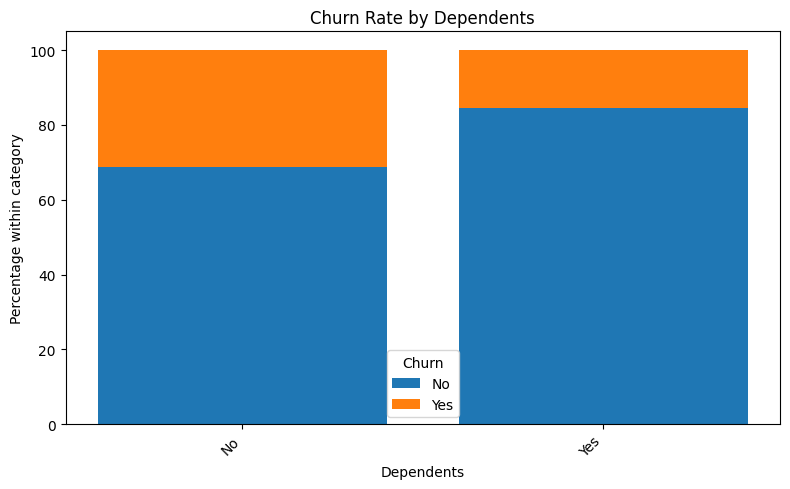

Contingency table:
shape: (2, 3)
┌────────────┬──────┬──────┐
│ Dependents ┆ No   ┆ Yes  │
│ ---        ┆ ---  ┆ ---  │
│ str        ┆ u32  ┆ u32  │
╞════════════╪══════╪══════╡
│ No         ┆ 2722 ┆ 1237 │
│ Yes        ┆ 1417 ┆ 258  │
└────────────┴──────┴──────┘
Rates:
shape: (2, 6)
┌────────────┬──────┬──────┬───────┬────────┬─────────┐
│ Dependents ┆ No   ┆ Yes  ┆ total ┆ No_pct ┆ Yes_pct │
│ ---        ┆ ---  ┆ ---  ┆ ---   ┆ ---    ┆ ---     │
│ str        ┆ u32  ┆ u32  ┆ u32   ┆ f64    ┆ f64     │
╞════════════╪══════╪══════╪═══════╪════════╪═════════╡
│ No         ┆ 2722 ┆ 1237 ┆ 3959  ┆ 68.75  ┆ 31.25   │
│ Yes        ┆ 1417 ┆ 258  ┆ 1675  ┆ 84.6   ┆ 15.4    │
└────────────┴──────┴──────┴───────┴────────┴─────────┘
Chi-square statistic: 150.7244276358448
P-value: 1.2039807736982936e-34




In [131]:
analyze_categorical_vs_churn(df_eda_selected, "Dependents")

The data supports this hypothesis.

From the contingency table:

- Customers without dependents:  
  - Churn rate ≈ **31.25%** (1237 out of 3959)

- Customers with dependents:  
  - Churn rate ≈ **15.40%** (258 out of 1675)

This represents a substantial difference of approximately **16 percentage points**, indicating that customers with dependents churn significantly less often.

The Chi-Square test confirms that this relationship is statistically significant:

- χ² = 150.72  
- p-value ≈ 1.20e-34  

**Interpretation**

The results suggest that having dependents is strongly associated with lower churn rates in this dataset.

This may reflect greater reliance on stable services within households, leading to higher switching costs and reduced likelihood of cancellation.

However, this relationship should not be interpreted as causal. It may also be influenced by other correlated factors such as contract type, tenure, or overall service usage.

The magnitude of the difference suggests that this variable is not only statistically significant but also practically meaningful, making it a strong candidate for inclusion in predictive models.

### Churn and tenure

**Hypothesis**

Customers with longer tenure may be less likely to churn compared to newer customers.

One possible explanation is that customers who have remained with the company for a longer period have already passed the early stages where churn risk is typically highest. Over time, they may develop familiarity with the service, integrate it into their daily usage, or benefit from contracts and bundled services, all of which can reduce the likelihood of switching providers.

**Interpretation (intuition before testing)**

This reflects a common pattern in subscription-based businesses, where churn risk is often highest in the early lifecycle and decreases as customer tenure increases.

This effect is sometimes associated with:

- increased customer familiarity with the service  
- higher switching costs over time  
- or a form of customer loyalty developed through continued usage  

However, it is important to verify this pattern using the data, as tenure may also be correlated with other variables such as contract type or service adoption.

**Observation**


===== Analysis for: tenure =====



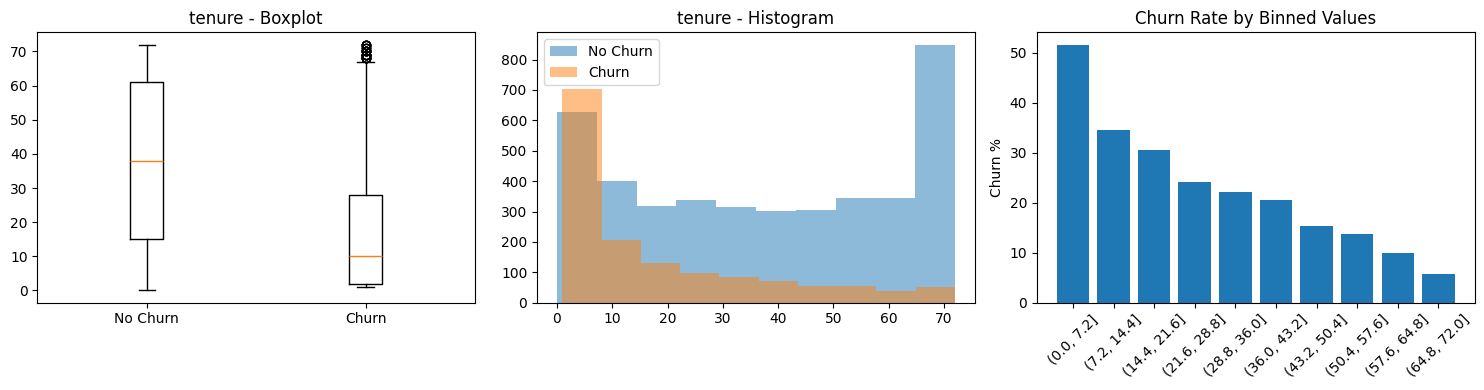


--- Statistical Tests ---

Welch t-test:
  t-statistic = -31.8298, p-value = 3.3594e-194

Mann-Whitney U test:
  U-statistic = 1599990.0000, p-value = 3.1727e-169
  AUC interpretation ≈ 0.2586

Brown-Forsythe test (variance):
  statistic = 381.4090, p-value = 3.0642e-82




In [132]:
analyze_continuous_vs_churn(df_eda_selected, "tenure")

The analysis shows a strong relationship between tenure and churn.

Customers with very low tenure exhibit the highest churn rates, with over **50% of customers in the earliest tenure group (0–7 months)** churning.

As tenure increases, churn rates decrease substantially. Customers with tenure above **50 months** show significantly lower churn rates, often below **10%**.

This pattern is consistent across both visualizations and statistical tests.

**Statistical Evidence**

All applied statistical tests confirm that the difference between churned and non-churned customers is highly significant:

- **Welch’s t-test (mean difference):**  
  t-statistic = -34.82, p-value ≈ 3.36e-194  
  → Indicates a substantial difference in average tenure between the two groups.

- **Mann–Whitney U test (distribution shift):**  
  U-statistic = 1,599,990, p-value ≈ 3.1727e-169  
  AUC ≈ **0.26**  
  → Suggests that churned customers tend to have significantly lower tenure than non-churned customers.  
  (An AUC far from 0.5 indicates strong separability between the groups.)

- **Brown–Forsythe test (variance difference):**  
  statistic = 381.4090, p-value ≈ 3.06e-82  
  → Indicates that the spread of tenure differs significantly between churned and non-churned customers.

**Interpretation**

The results strongly support the hypothesis that customers with longer tenure are less likely to churn.

This reflects a typical **customer lifecycle effect**, where churn risk is highest during the early stages of the customer relationship and decreases over time.

Customers who remain longer are more likely to:

- integrate the service into their daily usage  
- face higher switching costs  
- or be committed through longer-term contracts  

It is important to note that tenure is inherently linked to churn behavior, as customers who churn early cannot accumulate high tenure. Therefore, while tenure is a very strong predictive feature, its relationship with churn should be interpreted as **predictive rather than causal**.

The strength of both the statistical results and the observed effect size suggests that tenure will likely be one of the most important variables in predictive modeling.

### Churn and MultipleLines

**Hypothesis**

Customers with multiple phone lines may be less likely to churn compared to those with a single line.

One possible explanation is that customers using multiple lines are more deeply integrated into the service, potentially representing households or more complex usage patterns. This increased dependency may lead to higher switching costs and a lower likelihood of cancellation.

It is important to note that the category "No phone service" represents customers who do not use phone services at all, and therefore reflects a fundamentally different type of customer. As such, comparisons between categories should be interpreted carefully.

**Observation**


===== Analysis for: MultipleLines =====

Bar chart:


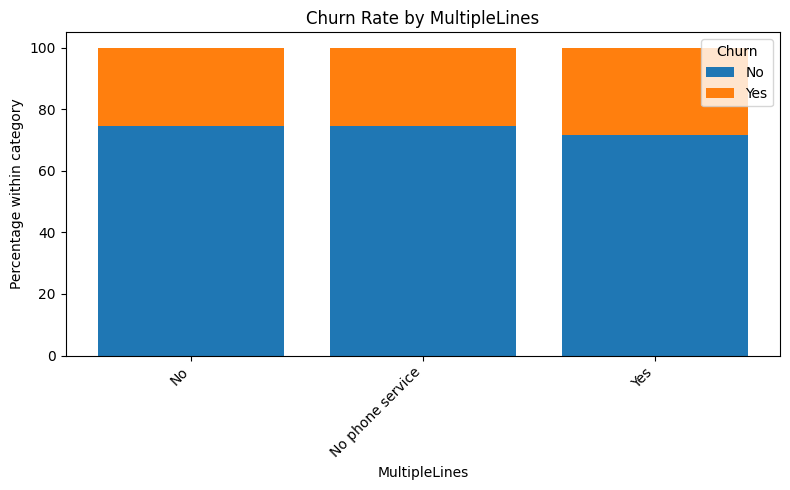

Contingency table:
shape: (3, 3)
┌──────────────────┬──────┬─────┐
│ MultipleLines    ┆ No   ┆ Yes │
│ ---              ┆ ---  ┆ --- │
│ str              ┆ u32  ┆ u32 │
╞══════════════════╪══════╪═════╡
│ No               ┆ 2035 ┆ 688 │
│ No phone service ┆ 388  ┆ 133 │
│ Yes              ┆ 1716 ┆ 674 │
└──────────────────┴──────┴─────┘
Rates:
shape: (3, 6)
┌──────────────────┬──────┬─────┬───────┬────────┬─────────┐
│ MultipleLines    ┆ No   ┆ Yes ┆ total ┆ No_pct ┆ Yes_pct │
│ ---              ┆ ---  ┆ --- ┆ ---   ┆ ---    ┆ ---     │
│ str              ┆ u32  ┆ u32 ┆ u32   ┆ f64    ┆ f64     │
╞══════════════════╪══════╪═════╪═══════╪════════╪═════════╡
│ No               ┆ 2035 ┆ 688 ┆ 2723  ┆ 74.73  ┆ 25.27   │
│ No phone service ┆ 388  ┆ 133 ┆ 521   ┆ 74.47  ┆ 25.53   │
│ Yes              ┆ 1716 ┆ 674 ┆ 2390  ┆ 71.8   ┆ 28.2    │
└──────────────────┴──────┴─────┴───────┴────────┴─────────┘
Chi-square statistic: 5.921824898425779
P-value: 0.05177165660725063




In [133]:
analyze_categorical_vs_churn(df_eda_selected, "MultipleLines")

The data does not strongly support this hypothesis.

From the contingency table:

- Customers with a single line:  
  - Churn rate ≈ **25.27%**

- Customers with no phone service:  
  - Churn rate ≈ **25.53%**

- Customers with multiple lines:  
  - Churn rate ≈ **28.20%**

Interestingly, customers with multiple lines exhibit a slightly **higher churn rate** compared to both single-line customers and those without phone service.

Additionally, customers with no phone service and those with a single line show **almost identical churn rates**, suggesting very similar behavior between these two groups.

The Chi-Square test indicates that the relationship is bordering statistical significance:

- χ² = 5.921  
- p-value ≈ 0.051  

However, the magnitude of the difference between groups is relatively small.

**Interpretation**

The results suggest that the number of phone lines is not a strong driver of churn behavior in this dataset.

The differences in churn rates between categories are modest (approximately 3 percentage points), indicating limited practical impact.

The similarity in churn rates between customers with no phone service and those with a single line suggests that simply having access to phone service does not meaningfully influence churn.

Furthermore, the slightly higher churn rate among customers with multiple lines contradicts the initial expectation that increased service complexity leads to higher retention.

This may indicate that:

- multiple lines do not significantly increase customer dependency  
- or that this variable does not fully capture overall service engagement  

Due to the results of chi-sqaure test and simplifying model structure we will drop this variable from dataset.

### Churn and InternetService

**Hypothesis**

Customer churn may vary depending on the type of internet service.

Different internet service types (e.g., DSL vs Fiber optic) may offer different levels of performance, pricing, and reliability, which can influence customer satisfaction and, consequently, churn behavior.

Additionally, customers without internet service may represent a distinct group with different usage patterns and potentially different drivers of churn.

Therefore, we expect to observe differences in churn rates across internet service categories.

**Observation**


===== Analysis for: InternetService =====

Bar chart:


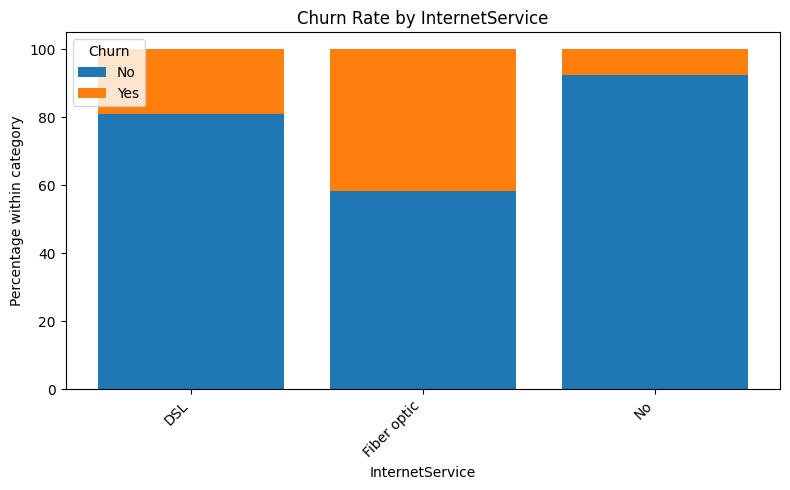

Contingency table:
shape: (3, 3)
┌─────────────────┬──────┬──────┐
│ InternetService ┆ No   ┆ Yes  │
│ ---             ┆ ---  ┆ ---  │
│ str             ┆ u32  ┆ u32  │
╞═════════════════╪══════╪══════╡
│ DSL             ┆ 1563 ┆ 366  │
│ Fiber optic     ┆ 1444 ┆ 1036 │
│ No              ┆ 1132 ┆ 93   │
└─────────────────┴──────┴──────┘
Rates:
shape: (3, 6)
┌─────────────────┬──────┬──────┬───────┬────────┬─────────┐
│ InternetService ┆ No   ┆ Yes  ┆ total ┆ No_pct ┆ Yes_pct │
│ ---             ┆ ---  ┆ ---  ┆ ---   ┆ ---    ┆ ---     │
│ str             ┆ u32  ┆ u32  ┆ u32   ┆ f64    ┆ f64     │
╞═════════════════╪══════╪══════╪═══════╪════════╪═════════╡
│ DSL             ┆ 1563 ┆ 366  ┆ 1929  ┆ 81.03  ┆ 18.97   │
│ Fiber optic     ┆ 1444 ┆ 1036 ┆ 2480  ┆ 58.23  ┆ 41.77   │
│ No              ┆ 1132 ┆ 93   ┆ 1225  ┆ 92.41  ┆ 7.59    │
└─────────────────┴──────┴──────┴───────┴────────┴─────────┘
Chi-square statistic: 577.5147433227115
P-value: 3.9288629404738406e-126




In [134]:
analyze_categorical_vs_churn(df_eda_selected, "InternetService")

The data shows a strong relationship between internet service type and churn.

From the contingency table:

- DSL customers:  
  - Churn rate ≈ **18.97%**

- Fiber optic customers:  
  - Churn rate ≈ **41.77%**

- Customers without internet service:  
  - Churn rate ≈ **7.59%**

Fiber optic customers exhibit **substantially higher churn rates**, more than double those of DSL customers and significantly higher than customers without internet service.

The Chi-Square test confirms that this relationship is highly statistically significant:

- χ² = 577.51  
- p-value ≈ 3.93e-126  

**Interpretation**

The results indicate that internet service type is a strong driver of churn behavior in this dataset.

In particular, fiber optic customers show markedly higher churn rates. This may reflect differences in pricing, customer expectations, or service experience. Higher-tier services often come with increased expectations, and any dissatisfaction may lead to a higher likelihood of switching providers.

At the same time, customers without internet service exhibit the lowest churn rates, suggesting that customers with simpler or more limited service usage may be less likely to leave.

It is important to note that this relationship should not be interpreted as causal. Internet service type may be correlated with other factors such as pricing, contract type, or customer segment, which may also influence churn.

The magnitude of the observed differences suggests that this variable is both **statistically significant and practically important**, making it one of the key features for predictive modeling.

### Churn and OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies

All of these variables represent additional services offered on top of a standard internet subscription.

**Hypothesis**

Customers who subscribe to these additional services may be less likely to churn, as they are more engaged with the provider and may face higher switching costs.

Therefore, we expect to observe meaningful differences in churn rates between customers who use these services ("Yes") and those who do not ("No").

At the same time, all of these variables include a "No internet service" category, which represents a distinct group of customers without access to these services. This group should be interpreted separately, as it does not reflect low engagement but rather absence of the underlying service.

**Observation**


===== Analysis for: OnlineSecurity =====

Bar chart:


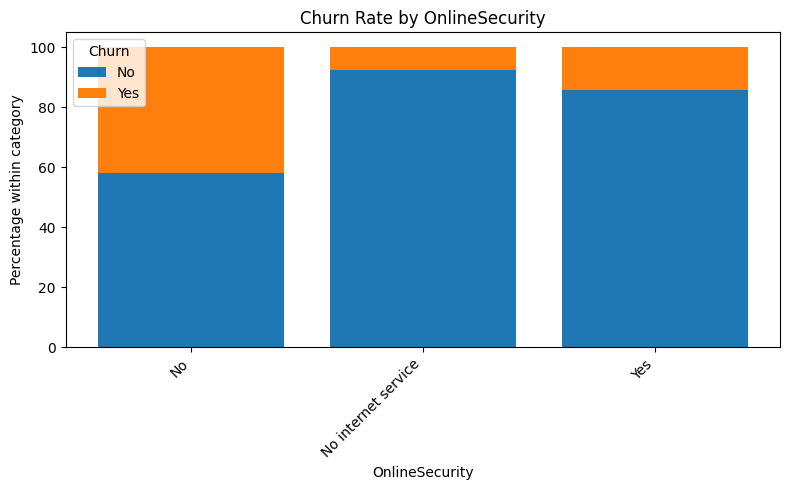

Contingency table:
shape: (3, 3)
┌─────────────────────┬──────┬──────┐
│ OnlineSecurity      ┆ No   ┆ Yes  │
│ ---                 ┆ ---  ┆ ---  │
│ str                 ┆ u32  ┆ u32  │
╞═════════════════════╪══════╪══════╡
│ No                  ┆ 1616 ┆ 1171 │
│ No internet service ┆ 1132 ┆ 93   │
│ Yes                 ┆ 1391 ┆ 231  │
└─────────────────────┴──────┴──────┘
Rates:
shape: (3, 6)
┌─────────────────────┬──────┬──────┬───────┬────────┬─────────┐
│ OnlineSecurity      ┆ No   ┆ Yes  ┆ total ┆ No_pct ┆ Yes_pct │
│ ---                 ┆ ---  ┆ ---  ┆ ---   ┆ ---    ┆ ---     │
│ str                 ┆ u32  ┆ u32  ┆ u32   ┆ f64    ┆ f64     │
╞═════════════════════╪══════╪══════╪═══════╪════════╪═════════╡
│ No                  ┆ 1616 ┆ 1171 ┆ 2787  ┆ 57.98  ┆ 42.02   │
│ No internet service ┆ 1132 ┆ 93   ┆ 1225  ┆ 92.41  ┆ 7.59    │
│ Yes                 ┆ 1391 ┆ 231  ┆ 1622  ┆ 85.76  ┆ 14.24   │
└─────────────────────┴──────┴──────┴───────┴────────┴─────────┘
Chi-square statisti

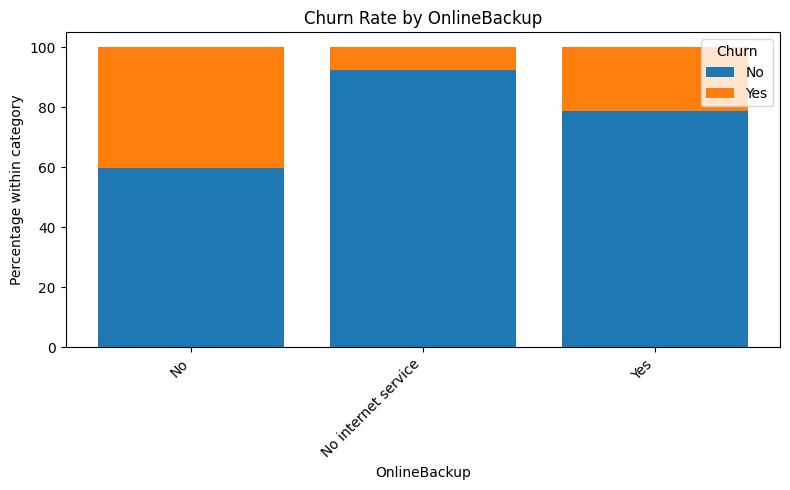

Contingency table:
shape: (3, 3)
┌─────────────────────┬──────┬─────┐
│ OnlineBackup        ┆ No   ┆ Yes │
│ ---                 ┆ ---  ┆ --- │
│ str                 ┆ u32  ┆ u32 │
╞═════════════════════╪══════╪═════╡
│ No                  ┆ 1481 ┆ 990 │
│ No internet service ┆ 1132 ┆ 93  │
│ Yes                 ┆ 1526 ┆ 412 │
└─────────────────────┴──────┴─────┘
Rates:
shape: (3, 6)
┌─────────────────────┬──────┬─────┬───────┬────────┬─────────┐
│ OnlineBackup        ┆ No   ┆ Yes ┆ total ┆ No_pct ┆ Yes_pct │
│ ---                 ┆ ---  ┆ --- ┆ ---   ┆ ---    ┆ ---     │
│ str                 ┆ u32  ┆ u32 ┆ u32   ┆ f64    ┆ f64     │
╞═════════════════════╪══════╪═════╪═══════╪════════╪═════════╡
│ No                  ┆ 1481 ┆ 990 ┆ 2471  ┆ 59.94  ┆ 40.06   │
│ No internet service ┆ 1132 ┆ 93  ┆ 1225  ┆ 92.41  ┆ 7.59    │
│ Yes                 ┆ 1526 ┆ 412 ┆ 1938  ┆ 78.74  ┆ 21.26   │
└─────────────────────┴──────┴─────┴───────┴────────┴─────────┘
Chi-square statistic: 485.20142146028

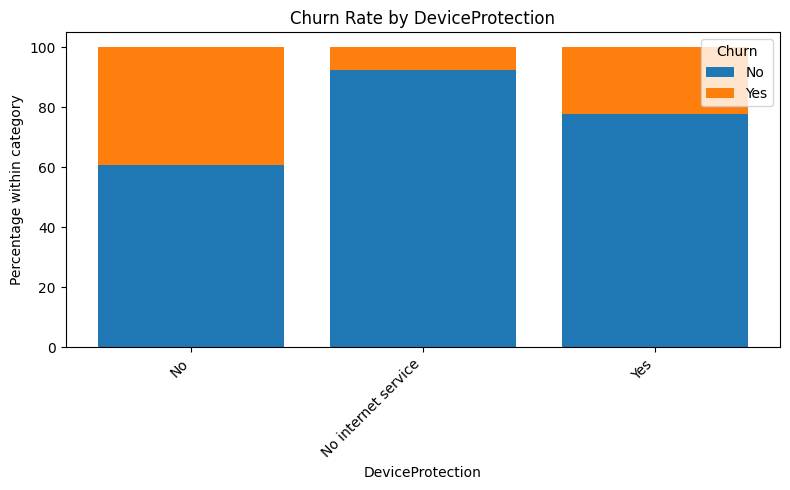

Contingency table:
shape: (3, 3)
┌─────────────────────┬──────┬─────┐
│ DeviceProtection    ┆ No   ┆ Yes │
│ ---                 ┆ ---  ┆ --- │
│ str                 ┆ u32  ┆ u32 │
╞═════════════════════╪══════╪═════╡
│ No                  ┆ 1494 ┆ 969 │
│ No internet service ┆ 1132 ┆ 93  │
│ Yes                 ┆ 1513 ┆ 433 │
└─────────────────────┴──────┴─────┘
Rates:
shape: (3, 6)
┌─────────────────────┬──────┬─────┬───────┬────────┬─────────┐
│ DeviceProtection    ┆ No   ┆ Yes ┆ total ┆ No_pct ┆ Yes_pct │
│ ---                 ┆ ---  ┆ --- ┆ ---   ┆ ---    ┆ ---     │
│ str                 ┆ u32  ┆ u32 ┆ u32   ┆ f64    ┆ f64     │
╞═════════════════════╪══════╪═════╪═══════╪════════╪═════════╡
│ No                  ┆ 1494 ┆ 969 ┆ 2463  ┆ 60.66  ┆ 39.34   │
│ No internet service ┆ 1132 ┆ 93  ┆ 1225  ┆ 92.41  ┆ 7.59    │
│ Yes                 ┆ 1513 ┆ 433 ┆ 1946  ┆ 77.75  ┆ 22.25   │
└─────────────────────┴──────┴─────┴───────┴────────┴─────────┘
Chi-square statistic: 451.05851339750

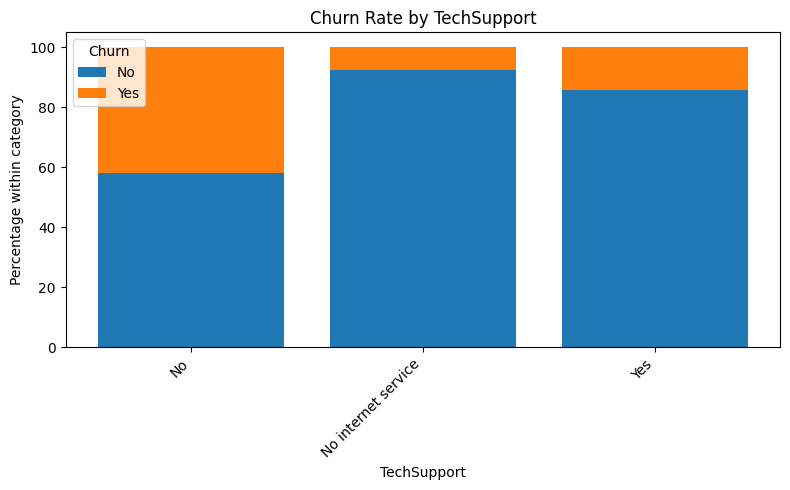

Contingency table:
shape: (3, 3)
┌─────────────────────┬──────┬──────┐
│ TechSupport         ┆ No   ┆ Yes  │
│ ---                 ┆ ---  ┆ ---  │
│ str                 ┆ u32  ┆ u32  │
╞═════════════════════╪══════╪══════╡
│ No                  ┆ 1614 ┆ 1169 │
│ No internet service ┆ 1132 ┆ 93   │
│ Yes                 ┆ 1393 ┆ 233  │
└─────────────────────┴──────┴──────┘
Rates:
shape: (3, 6)
┌─────────────────────┬──────┬──────┬───────┬────────┬─────────┐
│ TechSupport         ┆ No   ┆ Yes  ┆ total ┆ No_pct ┆ Yes_pct │
│ ---                 ┆ ---  ┆ ---  ┆ ---   ┆ ---    ┆ ---     │
│ str                 ┆ u32  ┆ u32  ┆ u32   ┆ f64    ┆ f64     │
╞═════════════════════╪══════╪══════╪═══════╪════════╪═════════╡
│ No                  ┆ 1614 ┆ 1169 ┆ 2783  ┆ 57.99  ┆ 42.01   │
│ No internet service ┆ 1132 ┆ 93   ┆ 1225  ┆ 92.41  ┆ 7.59    │
│ Yes                 ┆ 1393 ┆ 233  ┆ 1626  ┆ 85.67  ┆ 14.33   │
└─────────────────────┴──────┴──────┴───────┴────────┴─────────┘
Chi-square statisti

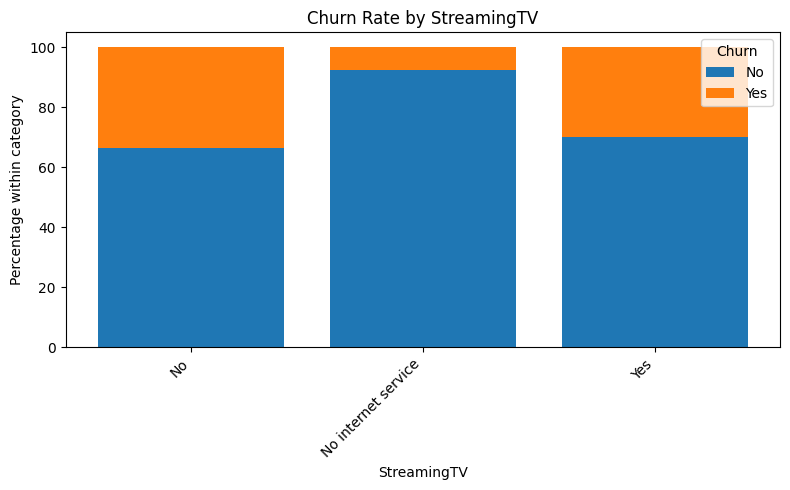

Contingency table:
shape: (3, 3)
┌─────────────────────┬──────┬─────┐
│ StreamingTV         ┆ No   ┆ Yes │
│ ---                 ┆ ---  ┆ --- │
│ str                 ┆ u32  ┆ u32 │
╞═════════════════════╪══════╪═════╡
│ No                  ┆ 1488 ┆ 750 │
│ No internet service ┆ 1132 ┆ 93  │
│ Yes                 ┆ 1519 ┆ 652 │
└─────────────────────┴──────┴─────┘
Rates:
shape: (3, 6)
┌─────────────────────┬──────┬─────┬───────┬────────┬─────────┐
│ StreamingTV         ┆ No   ┆ Yes ┆ total ┆ No_pct ┆ Yes_pct │
│ ---                 ┆ ---  ┆ --- ┆ ---   ┆ ---    ┆ ---     │
│ str                 ┆ u32  ┆ u32 ┆ u32   ┆ f64    ┆ f64     │
╞═════════════════════╪══════╪═════╪═══════╪════════╪═════════╡
│ No                  ┆ 1488 ┆ 750 ┆ 2238  ┆ 66.49  ┆ 33.51   │
│ No internet service ┆ 1132 ┆ 93  ┆ 1225  ┆ 92.41  ┆ 7.59    │
│ Yes                 ┆ 1519 ┆ 652 ┆ 2171  ┆ 69.97  ┆ 30.03   │
└─────────────────────┴──────┴─────┴───────┴────────┴─────────┘
Chi-square statistic: 295.00257728408

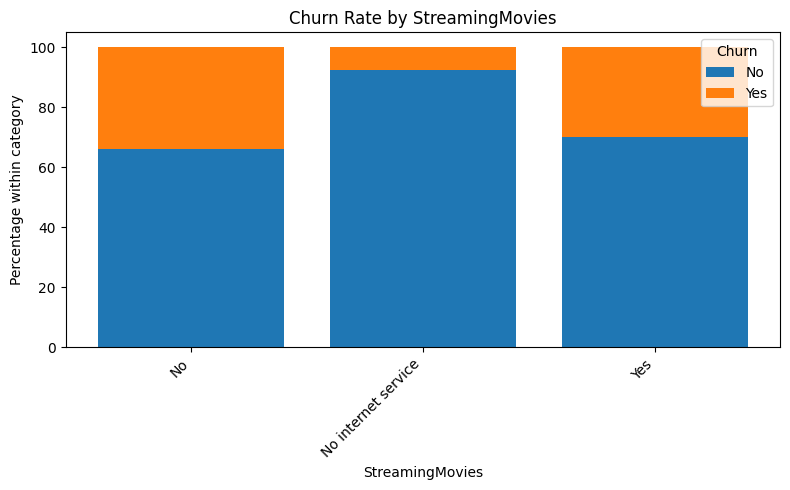

Contingency table:
shape: (3, 3)
┌─────────────────────┬──────┬─────┐
│ StreamingMovies     ┆ No   ┆ Yes │
│ ---                 ┆ ---  ┆ --- │
│ str                 ┆ u32  ┆ u32 │
╞═════════════════════╪══════╪═════╡
│ No                  ┆ 1473 ┆ 753 │
│ No internet service ┆ 1132 ┆ 93  │
│ Yes                 ┆ 1534 ┆ 649 │
└─────────────────────┴──────┴─────┘
Rates:
shape: (3, 6)
┌─────────────────────┬──────┬─────┬───────┬────────┬─────────┐
│ StreamingMovies     ┆ No   ┆ Yes ┆ total ┆ No_pct ┆ Yes_pct │
│ ---                 ┆ ---  ┆ --- ┆ ---   ┆ ---    ┆ ---     │
│ str                 ┆ u32  ┆ u32 ┆ u32   ┆ f64    ┆ f64     │
╞═════════════════════╪══════╪═════╪═══════╪════════╪═════════╡
│ No                  ┆ 1473 ┆ 753 ┆ 2226  ┆ 66.17  ┆ 33.83   │
│ No internet service ┆ 1132 ┆ 93  ┆ 1225  ┆ 92.41  ┆ 7.59    │
│ Yes                 ┆ 1534 ┆ 649 ┆ 2183  ┆ 70.27  ┆ 29.73   │
└─────────────────────┴──────┴─────┴───────┴────────┴─────────┘
Chi-square statistic: 297.65087719336

In [135]:
list_of_services = ["OnlineSecurity",
                        "OnlineBackup",
                        "DeviceProtection",
                        "TechSupport",
                        "StreamingTV",
                        "StreamingMovies"]

for service in list_of_services:
    analyze_categorical_vs_churn(df_eda_selected, service)


#### Summary of Additional Services

Across all additional services (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`), a consistent pattern emerges.

**Core Insight**

Customers who subscribe to **protective and support-related services** (`OnlineSecurity`, `TechSupport`, `DeviceProtection`, `OnlineBackup`) exhibit **significantly lower churn rates** compared to customers who do not.

For example:

- `OnlineSecurity`:  
  - No → **21.02% churn**  
  - Yes → **14.24% churn**

- `TechSupport`:  
  - No → **42.01% churn**  
  - Yes → **14.33% churn**

This suggests that these services are strong indicators of **customer engagement and retention**, likely due to increased switching costs and deeper integration into the provider’s ecosystem.

---

**Streaming Services Behave Differently**

In contrast, **entertainment services** (`StreamingTV`, `StreamingMovies`) show **much weaker relationships with churn**:

- `StreamingTV`:  
  - No → **33.51% churn**  
  - Yes → **30.03% churn**

- `StreamingMovies`:  
  - No → **33.83% churn**  
  - Yes → **29.73% churn**

While statistically significant, the effect size is relatively small, suggesting these services are **less important drivers of retention**.

---

**No Internet Service Group**

Across all variables, customers without internet service consistently show **very low churn (~7.4%)**.

This group behaves differently and likely represents customers using **only basic telecom services**, making them less exposed to factors driving churn in internet-based products.

---

**Statistical Significance**

All variables show **highly significant relationships with churn** (p-values ≪ 0.001), confirming that the observed differences are unlikely to be due to random variation.

---

**Conclusion**

- **Security and support services → strong negative relationship with churn**
- **Streaming services → weak relationship with churn**
- **No internet customers → structurally different, low churn group**

This suggests that not all services contribute equally to retention, and that **type of service matters more than number of services alone**.

These findings motivate further feature engineering, such as:
- grouping services into categories (core vs entertainment)
- creating a total number of services feature
- exploring interaction effects between services

### Churn and Contract

The `Contract` variable describes the length of the customer’s agreement with the provider (`Month-to-month`, `One year`, `Two year`).

**Hypothesis**

Customers with longer-term contracts are expected to have lower churn rates compared to those on month-to-month plans.

This expectation is based on two main factors:

- **Switching constraints**  
  Longer contracts may include penalties or contractual obligations that make it more difficult or costly for customers to leave before the contract expires.

- **Customer commitment and selection effect**  
  Customers who choose longer-term contracts may already be more satisfied or confident in the service, indicating a lower underlying propensity to churn.

In contrast, customers on month-to-month contracts have greater flexibility to cancel at any time, which may lead to higher observed churn rates.

Therefore, we expect to observe a strong relationship between contract type and churn, with churn decreasing as contract length increases.

**Observation**


===== Analysis for: Contract =====

Bar chart:


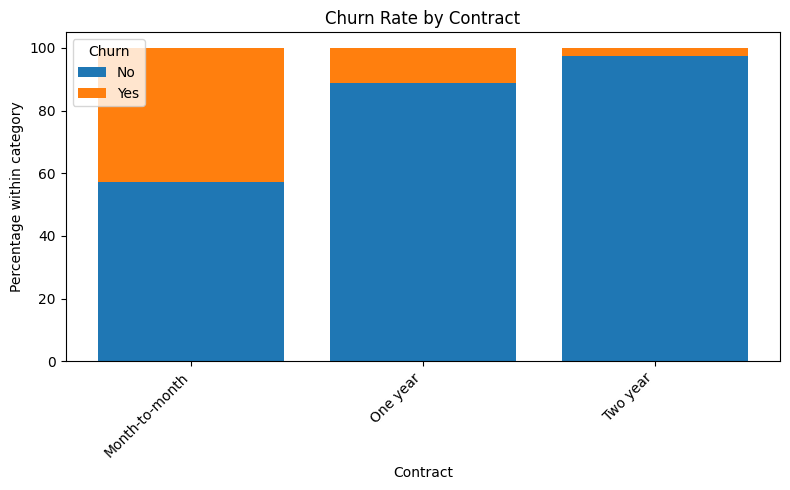

Contingency table:
shape: (3, 3)
┌────────────────┬──────┬──────┐
│ Contract       ┆ No   ┆ Yes  │
│ ---            ┆ ---  ┆ ---  │
│ str            ┆ u32  ┆ u32  │
╞════════════════╪══════╪══════╡
│ Month-to-month ┆ 1788 ┆ 1329 │
│ One year       ┆ 1043 ┆ 130  │
│ Two year       ┆ 1308 ┆ 36   │
└────────────────┴──────┴──────┘
Rates:
shape: (3, 6)
┌────────────────┬──────┬──────┬───────┬────────┬─────────┐
│ Contract       ┆ No   ┆ Yes  ┆ total ┆ No_pct ┆ Yes_pct │
│ ---            ┆ ---  ┆ ---  ┆ ---   ┆ ---    ┆ ---     │
│ str            ┆ u32  ┆ u32  ┆ u32   ┆ f64    ┆ f64     │
╞════════════════╪══════╪══════╪═══════╪════════╪═════════╡
│ Month-to-month ┆ 1788 ┆ 1329 ┆ 3117  ┆ 57.36  ┆ 42.64   │
│ One year       ┆ 1043 ┆ 130  ┆ 1173  ┆ 88.92  ┆ 11.08   │
│ Two year       ┆ 1308 ┆ 36   ┆ 1344  ┆ 97.32  ┆ 2.68    │
└────────────────┴──────┴──────┴───────┴────────┴─────────┘
Chi-square statistic: 950.6290739916736
P-value: 3.745582905780251e-207




In [136]:
analyze_categorical_vs_churn(df_eda_selected, "Contract")

The results strongly support the initial hypothesis that contract length is negatively associated with churn.

- `Month-to-month`: **42.64% churn**
- `One year`: **11.08% churn**
- `Two year`: **2.68% churn**

This represents a substantial decrease in churn as contract length increases.

Customers on month-to-month contracts churn at nearly **15 times the rate** of customers on two-year contracts.

---

The Chi-Square test confirms that this relationship is highly statistically significant:

- χ² = 950.63  
- p-value ≈ 3.74e-207  

This indicates a very strong dependence between contract type and churn.

---

**Interpretation**

Two key effects are likely driving this relationship:

- **Contractual constraints (lock-in effect)**  
  Longer-term contracts reduce the ability of customers to leave freely, either due to penalties or fixed commitments.

- **Selection effect**  
  Customers who choose longer contracts may already have higher satisfaction or trust in the service, making them inherently less likely to churn.

---

**Conclusion**

Contract type appears to be one of the strongest predictors of churn in the dataset.

This variable will likely play a critical role in predictive modeling and may dominate other features if not carefully evaluated.

### Churn and PaperlessBilling

**Hypothesis**

Customers using paperless billing may exhibit different churn behavior compared to those who do not.

One possible explanation is that paperless billing may be associated with a more digitally engaged customer profile, which could correlate with greater use of online services and potentially stronger integration into the provider’s ecosystem.

At the same time, paperless billing may also be more common among customers on flexible, self-managed plans, which could be associated with a higher willingness to switch providers.

Therefore, while we expect a meaningful relationship between paperless billing and churn, the direction of the effect is not entirely clear in advance and should be determined empirically.

**Observation**


===== Analysis for: PaperlessBilling =====

Bar chart:


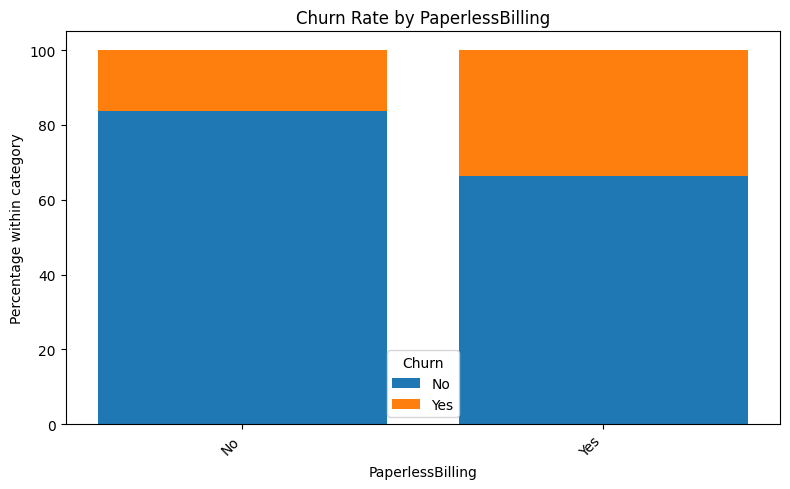

Contingency table:
shape: (2, 3)
┌──────────────────┬──────┬──────┐
│ PaperlessBilling ┆ No   ┆ Yes  │
│ ---              ┆ ---  ┆ ---  │
│ str              ┆ u32  ┆ u32  │
╞══════════════════╪══════╪══════╡
│ No               ┆ 1927 ┆ 374  │
│ Yes              ┆ 2212 ┆ 1121 │
└──────────────────┴──────┴──────┘
Rates:
shape: (2, 6)
┌──────────────────┬──────┬──────┬───────┬────────┬─────────┐
│ PaperlessBilling ┆ No   ┆ Yes  ┆ total ┆ No_pct ┆ Yes_pct │
│ ---              ┆ ---  ┆ ---  ┆ ---   ┆ ---    ┆ ---     │
│ str              ┆ u32  ┆ u32  ┆ u32   ┆ f64    ┆ f64     │
╞══════════════════╪══════╪══════╪═══════╪════════╪═════════╡
│ No               ┆ 1927 ┆ 374  ┆ 2301  ┆ 83.75  ┆ 16.25   │
│ Yes              ┆ 2212 ┆ 1121 ┆ 3333  ┆ 66.37  ┆ 33.63   │
└──────────────────┴──────┴──────┴───────┴────────┴─────────┘
Chi-square statistic: 210.02551720280988
P-value: 1.356121736013452e-47




In [137]:
analyze_categorical_vs_churn(df_eda_selected, "PaperlessBilling")


The results show a clear difference in churn rates between customers with and without paperless billing:

- `PaperlessBilling = No`: **16.25% churn**
- `PaperlessBilling = Yes`: **33.63% churn**

Customers using paperless billing churn at **more than double the rate** of those receiving paper bills.

---

The Chi-Square test confirms that this relationship is highly statistically significant:

- χ² = 210.03  
- p-value ≈ 1.36e-47  

This indicates a strong association between paperless billing and churn.

---

**Interpretation**

Contrary to the initial expectation, customers using paperless billing are significantly more likely to churn.

Several possible explanations may account for this:

- **Lower switching friction**  
  Customers already interacting digitally may find it easier to switch providers, as they are less tied to traditional billing processes.

- **Customer segment differences**  
  Paperless billing may be more common among younger or more price-sensitive customers, who are generally more likely to switch providers.

- **Association with flexible contracts**  
  Paperless billing may correlate with month-to-month contracts or online payment methods, which themselves are associated with higher churn.

---

**Important Note**

This relationship should not be interpreted as causal.

Paperless billing itself is unlikely to directly cause churn. Instead, it may act as a **proxy variable** capturing underlying customer behavior or preferences.

---

**Conclusion**

Paperless billing is a strong predictor of churn in this dataset, but its effect is likely indirect and driven by broader behavioral or contractual factors.

This makes it a useful feature for modeling, but one that should be interpreted with caution.

### Churn and PaymentMethod

The `PaymentMethod` variable describes how customers pay for their services (e.g., electronic check, bank transfer, credit card, mailed check).

**Hypothesis**

Payment method may be associated with customer churn, as it can reflect both customer behavior and the level of automation in the billing process.

Customers using **automatic payment methods** (e.g., bank transfer or credit card) may be less likely to churn, as their payments are integrated into a recurring system with minimal effort required. This reduces friction in maintaining the service and may indicate a higher level of commitment.

In contrast, customers using **manual payment methods** (e.g., mailed checks or electronic checks) may be more likely to churn. These methods require more active involvement and may reflect lower engagement or a weaker relationship with the provider.

Therefore, we expect to observe lower churn rates among customers with automatic payment methods and higher churn rates among those using manual or less automated methods.

**Observation**


===== Analysis for: PaymentMethod =====

Bar chart:


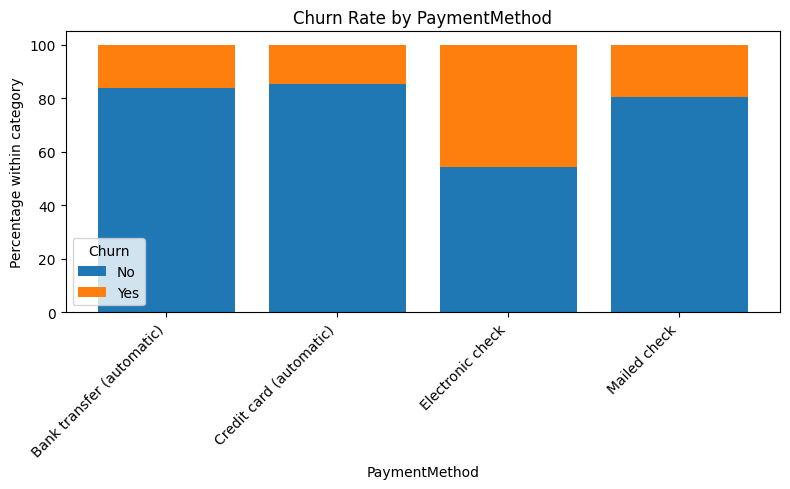

Contingency table:
shape: (4, 3)
┌───────────────────────────┬──────┬─────┐
│ PaymentMethod             ┆ No   ┆ Yes │
│ ---                       ┆ ---  ┆ --- │
│ str                       ┆ u32  ┆ u32 │
╞═══════════════════════════╪══════╪═════╡
│ Bank transfer (automatic) ┆ 1041 ┆ 203 │
│ Credit card (automatic)   ┆ 1040 ┆ 180 │
│ Electronic check          ┆ 1021 ┆ 863 │
│ Mailed check              ┆ 1037 ┆ 249 │
└───────────────────────────┴──────┴─────┘
Rates:
shape: (4, 6)
┌───────────────────────────┬──────┬─────┬───────┬────────┬─────────┐
│ PaymentMethod             ┆ No   ┆ Yes ┆ total ┆ No_pct ┆ Yes_pct │
│ ---                       ┆ ---  ┆ --- ┆ ---   ┆ ---    ┆ ---     │
│ str                       ┆ u32  ┆ u32 ┆ u32   ┆ f64    ┆ f64     │
╞═══════════════════════════╪══════╪═════╪═══════╪════════╪═════════╡
│ Bank transfer (automatic) ┆ 1041 ┆ 203 ┆ 1244  ┆ 83.68  ┆ 16.32   │
│ Credit card (automatic)   ┆ 1040 ┆ 180 ┆ 1220  ┆ 85.25  ┆ 14.75   │
│ Electronic check        

In [138]:
analyze_categorical_vs_churn(df_eda_selected, "PaymentMethod")

The results show substantial differences in churn rates across payment methods:

- `Bank transfer (automatic)`: **16.32% churn**
- `Credit card (automatic)`: **15.75% churn**
- `Mailed check`: **19.36% churn**
- `Electronic check`: **45.81% churn**

Customers using **electronic checks churn at nearly three times the rate** of those using automatic payment methods.

---

The Chi-Square test confirms that the relationship is highly statistically significant:

- χ² = 546.35  
- p-value ≈ 4.30e-118

This indicates a strong dependence between payment method and churn.

---

**Interpretation**

The results strongly support the hypothesis that **payment automation is associated with lower churn**, but they also reveal an important nuance.

- **Automatic payments (bank transfer, credit card)**  
  These customers exhibit the lowest churn rates (~15–17%), suggesting higher commitment and lower friction in maintaining the service.

- **Mailed checks**  
  Despite being a manual method, churn remains relatively low (~19%), which may indicate a more stable or less price-sensitive customer segment.

- **Electronic checks**  
  This group stands out with a significantly higher churn rate (~45%).  

  This suggests that electronic check users represent a distinct segment, potentially characterized by:
  - lower commitment
  - higher price sensitivity
  - preference for flexible, short-term arrangements

---

**Important Note**

The observed relationship is unlikely to be purely causal.

Payment method may act as a **proxy variable** capturing underlying customer characteristics such as contract type, tenure, or customer segment.

For example, electronic check usage may be correlated with month-to-month contracts, which are already associated with higher churn.

---

**Conclusion**

Payment method is a strong predictor of churn, with **electronic check users representing a high-risk segment**.

This variable provides valuable information for modeling, but its interpretation should consider its interaction with other features such as contract type and customer tenure.

### Monthly Charges

The `MonthlyCharges` variable represents the amount billed to the customer on a monthly basis.

**Hypothesis**

Monthly charges may be associated with customer churn, as pricing is often an important factor in customer decision-making.

One possible expectation is that customers with **higher monthly charges** may be more likely to churn, as the financial burden increases and customers may seek cheaper alternatives.

However, this relationship is not necessarily straightforward.

Higher monthly charges may also reflect customers who subscribe to **more services or premium offerings**, which could increase their engagement and make them less likely to leave.

Conversely, customers with lower monthly charges may be using only basic services, which could make switching providers easier.

Therefore, we expect to observe a relationship between monthly charges and churn, but the direction and shape of this relationship may not be strictly linear and should be evaluated empirically.

**Observation**


===== Analysis for: MonthlyCharges =====



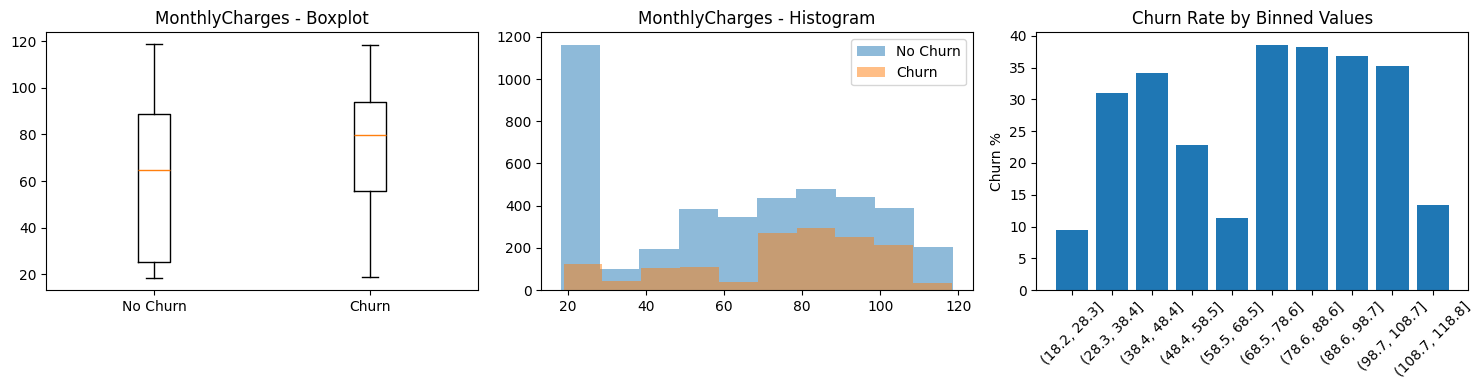


--- Statistical Tests ---

Welch t-test:
  t-statistic = 15.9444, p-value = 3.3615e-55

Mann-Whitney U test:
  U-statistic = 3813402.0000, p-value = 1.2215e-40
  AUC interpretation ≈ 0.6163

Brown-Forsythe test (variance):
  statistic = 290.6256, p-value = 1.3980e-63




In [139]:
analyze_continuous_vs_churn(df_eda_selected, "MonthlyCharges")

The analysis shows that customers who churn tend to have higher monthly charges on average. However, the relationship is not clean or strictly monotonic, and there is substantial overlap between churned and non-churned customers.

While statistical tests indicate a significant difference between groups, the visualizations suggest that the predictive power of this variable in its raw form is limited.

---

**Interpretation**

The lack of a clear pattern suggests that `MonthlyCharges` is not a pure price variable.

Instead, it likely reflects a combination of factors, including:

- number of subscribed services  
- type of services (basic vs premium)  
- customer segment characteristics  

As a result, higher monthly charges may not directly cause churn, but rather indicate customers with more complex service configurations or different usage patterns.

---

**Conclusion**

In its current form, `MonthlyCharges` is a confounded variable and does not provide a clean signal for churn prediction.

To make this variable more informative, it may be beneficial to transform it into more meaningful features, such as:

- average price per service  
- number of subscribed services  
- service bundle categories  

These transformations will be explored in the feature engineering stage.

### TotalCharges

The `TotalCharges` variable represents the cumulative amount a customer has paid over their lifetime with the company.

**Hypothesis**

At first glance, higher total charges might be associated with lower churn, as customers who have spent more money may appear more committed to the service.

However, this relationship is likely to be heavily influenced by **tenure** and **MonthlyCharge**.

Customers who have been with the company longer naturally accumulate higher total charges, and we have already observed that longer tenure is strongly associated with lower churn.

Therefore, `TotalCharges` may not provide independent information about churn, but rather act as a proxy for customer tenure.

As a result, we expect this variable to show a relationship with churn, but one that is largely redundant once tenure is taken into account.

**Observation**


===== Analysis for: TotalCharges =====



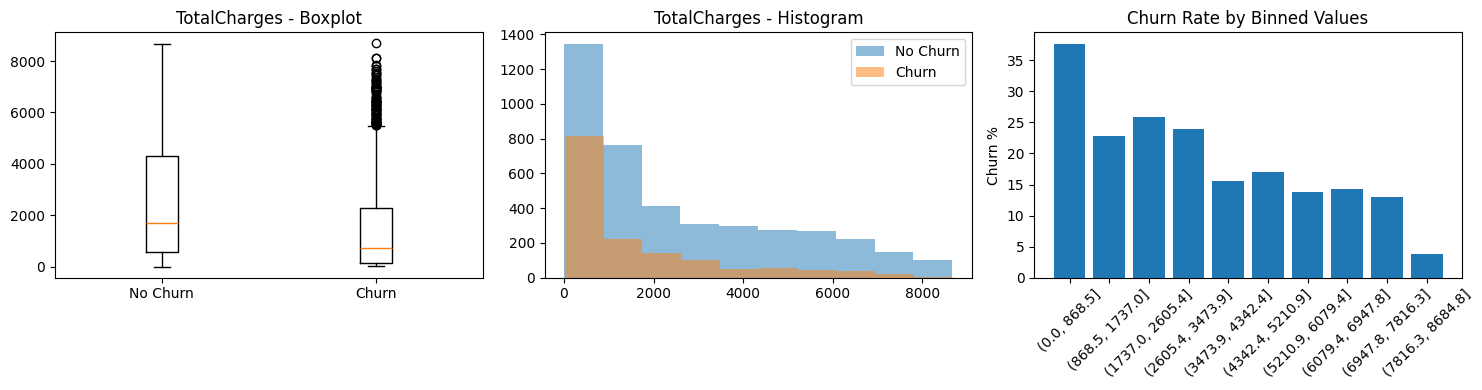


--- Statistical Tests ---

Welch t-test:
  t-statistic = -17.5288, p-value = 7.3843e-66

Mann-Whitney U test:
  U-statistic = 2150250.0000, p-value = 1.2892e-68
  AUC interpretation ≈ 0.3475

Brown-Forsythe test (variance):
  statistic = 152.5754, p-value = 1.3264e-34




In [140]:
analyze_continuous_vs_churn(df_eda_selected, "TotalCharges")

Customers who churn tend to have significantly lower total charges compared to those who remain.

- Mann–Whitney AUC ≈ **0.35**, indicating that churned customers generally have lower values
- All statistical tests show strong significance (p-value ≈ 0)

The binned analysis also shows a decreasing trend in churn as total charges increase.

---

**Interpretation**

At first glance, this might suggest that customers who have paid more are less likely to churn.

However, this interpretation would be misleading.

`TotalCharges` is fundamentally a **cumulative variable**, which is strongly driven by customer tenure:

```
TotalCharges ≈ MonthlyCharges × tenure
```

Since we have already established that longer-tenure customers are significantly less likely to churn, the observed relationship is largely a reflection of **customer lifetime**, not spending behavior.

In other words, customers with higher total charges are not necessarily more loyal because they paid more — they have simply **been customers for longer**.

---

**Conclusion**

`TotalCharges` does not represent an independent driver of churn, but rather acts as a proxy for tenure.

As a result:

- the variable is **highly correlated with tenure**
- its apparent predictive power is **redundant**
- it may introduce multicollinearity in modeling

For these reasons, `TotalCharges` will likely require transformation or exclusion during the feature engineering stage.

### Conclusion of the Relationship Analysis

The relationship analysis identified several variables with strong associations to churn, as well as others whose effect appears weaker or largely indirect.

The most important findings are:

Strong predictors of churn include:

 - `Contract`

 - `tenure`

 - `InternetService`

 - `PaymentMethod`

 - `PaperlessBilling`


Household-related variables such as `Partner` and `Dependents` also show meaningful relationships with churn, suggesting that customer stability and household structure may influence retention.

Among additional internet services, protective and support-related features (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`) appear to be associated with lower churn, while entertainment-related services (`StreamingTV`, `StreamingMovies`) show much weaker effects.

Some variables, such as `MonthlyCharges`, appear to be confounded and do not provide a clean standalone signal in their raw form.

Other variables, such as `TotalCharges`, are largely redundant, as their apparent relationship with churn is primarily explained by customer `tenure`.

Fetures with weak relationship with churn:

 - `MultipleLines`

We have decided to exclude `MultipleLines` from dataset for further analysis.

Overall, this analysis confirms that churn is influenced by a combination of:

 - customer lifecycle effects

 - contractual structure

 - service type and service engagement

 - billing and payment behavior

At the same time, the analysis also shows that not all statistically significant variables are equally useful or equally interpretable for modeling.

These findings provide a strong foundation for the next stage of the project: feature engineering, where the goal will be to:

 - address redundancy between variables

 - transform confounded variables into more meaningful representations

 - create aggregated features capturing broader behavioral patterns

 - prepare a clean feature set for predictive modeling

## Final Conclusion of Exploratory Data Analysis

The exploratory analysis provided a comprehensive understanding of the dataset, including data quality issues, variable distributions, and relationships with customer churn.

Several important insights emerged from this analysis:

- **Customer lifecycle effects play a major role in churn**
  - `tenure` is one of the strongest predictors, with churn heavily concentrated among newer customers.

- **Contract structure is a key driver of retention**
  - Customers on longer-term contracts exhibit dramatically lower churn rates compared to month-to-month customers.

- **Service engagement matters, but not uniformly**
  - Protective and support-related services (`OnlineSecurity`, `TechSupport`, etc.) are strongly associated with lower churn.
  - Entertainment services (`StreamingTV`, `StreamingMovies`) show much weaker effects.

- **Customer behavior and payment patterns are highly informative**
  - Payment method, particularly `Electronic check`, identifies a high-risk churn segment.
  - `PaperlessBilling` is associated with higher churn, likely reflecting customer behavior rather than a direct causal effect.

- **Some variables are confounded or redundant**
  - `MonthlyCharges` reflects a mixture of pricing and service composition, limiting its standalone interpretability.
  - `TotalCharges` is largely a function of tenure and does not provide independent information.

- **Household characteristics contribute to retention**
  - Customers with partners or dependents show significantly lower churn rates.

---

**Key Takeaways**

Churn behavior in this dataset appears to be driven by a combination of:

- customer lifecycle stage  
- contractual constraints  
- service engagement and product mix  
- payment behavior and customer segment  

At the same time, the analysis highlights that not all statistically significant variables are equally useful in their raw form.

---

**Next Steps**

Before proceeding to feature engineering, it is important to address **dependencies and relationships between variables**, including potential multicollinearity and redundancy identified during this analysis.

In the next notebook, we will:

- examine relationships between predictors  
- identify redundant or overlapping variables  
- design a consistent feature set for modeling  

Following this step, we will move to **feature engineering**, where insights from this analysis will be translated into more meaningful and model-ready features.

In [141]:
# save the data at the end of the notebook as input for the next notebook
df_eda_end = df_eda_selected.drop("MultipleLines") # proven to be not significant
df_eda_end.write_csv("data/processed/03_eda_train_df_end.csv")

### Recording the changes to dataset

We did some nontrivial changes to the dataset over the Exploratory Data Analysis. We need to keep data consistnet between train and test dataset. Even though we do not load test dataset at all in this notebook we will record changes that we did to the dataset in form of .json so later we can apply the same changes to the test dataste 

In [142]:
import json

feature_config = {
    "new_features": [
        {   "name": "SeniorCitizenRelevel",
            "source":{"name": "SeniorCitizen",
                      "data_type": "numeric"},
            "data_type": "string",
            "action": "relevel",
            "mapping": {1: "Yes", 0: "No"}
        }
    ],
    "dropped_features": ["customerID", "gender", "PhoneService", "MultipleLines","SeniorCitizen"],
    "missing_values_handelling_features":[
        {"name": "TotalCharges", 
        "action": "impute",
        "imputation_strategy": "constant",
        "fill_value": 0
        }
    ]
}


with open("./data/configs/01_eda.json", "w") as f:
    json.dump(feature_config, f)

When later creating pipeline to get test data alligned we will first create new features and then drop.